# Лабораторная работа №1
## Компьютерная геометрия

**Цель работы:** знакомство с параметрическим представлением прямой, отрезков, кривых. Проверка знаний основ библиотек NumPy и Matplotlib.

**Требования к оформлению:**
- Изображения должны четкими, достаточного размера и разрешения, например size=(5, 5) и dpi=200.
- На всех изображениях должна присутствовать сетка координат. Используйте ax.grid(True).
- Масштаб осей должен быть одинаков (почти во всех случаях). Используйте ax.set_aspect('equal').
- Нельзя пользоваться устаревшим интерфейсом а-ля Matlab, вызывая функции непосредственно из модуля pyplot (plt). Вместо этого пользуйтесь современным объектно-ориентированным интерфейсом и вызывайте функции - только из объекта Axies (ax) и в редких случаях из Figure (fig)

---
## Задание №1. Линейная интерполяция (LERP)

**Теория:** формула $\mathbf{p}(t) = \mathbf{p}_1(1-t) + \mathbf{p}_2 t$ называется линейной интерполяцией (LERP). При $t \in [0,1]$ точка движется между $\mathbf{p}_1$ и $\mathbf{p}_2$.

**Задачи:**
1. Задать отрезок точками 𝑃1 и 𝑃2 с радиус векторами 𝐩1 и 𝐩2. Отобразить на рисунке точки и их обозначения, как это показано на Рис. 1.
2. С помощью формулы для 𝐩(𝑡) = 𝐩1(1 − 𝑡) + 𝐩2𝑡 отобразить точку, расположенную в середине отрезка (точка 𝑀 на Рис. 1).
3. Создать ползунок, с помощью которого можно будет перемещать произвольную точку
отрезка от начальной точки 𝑃1 до конечной 𝑃2.
4. Сделайте так, чтобы точка двигалась в обратном направлении — от 𝑃2 к 𝑃1.
5. Не изменяя функции сделайте так, чтобы точка могла выходить за границы отрезка вобе стороны.
6. 

Координаты (все на прямой y=0):
  M2 (t=-2.0): (-20.00, 0.00)
  P1 (t=0): (-4.00, 0.00)
  M (t=0.5): (0.00, 0.00)
  P2 (t=1): (4.00, 0.00)
  M1 (t=3.0): (20.00, 0.00)
Диапазон ползунка: t ∈ [-3.0, 4.0]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, ToggleButtons
from IPython.display import display

# Настройки стиля согласно требованиям
plt.rcParams["figure.figsize"] = (8.0, 4.0)  # Как в 1 коде - широкий формат
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["grid.linestyle"] = "-"  # Сплошная сетка как в 1 коде
plt.rcParams["grid.color"] = "#b0b0b0"
plt.rcParams["grid.alpha"] = 0.7

# Исходные данные
P1 = np.array([-4.0, 0.0])
P2 = np.array([4.0, 0.0])
s = 2.0

def lerp(p1, p2, t):
    """Линейная интерполяция двух точек."""
    return p1 * (1.0 - t) + p2 * t

# Вычисляем фиксированные точки (они не меняются при движении ползунка)
M2 = lerp(P1, P2, -s)      # t = -2.0
M = lerp(P1, P2, 0.5)      # t = 0.5
M1 = lerp(P1, P2, 1.0 + s) # t = 3.0

def plot_lerp_extended(t, reverse):
    """
    Основная функция отрисовки.
    Использует чистый ООП-подход без вызовов plt.plot()
    """
    # Логика реверса
    t_eff = t if not reverse else 1.0 - t
    
    # Текущая точка
    X = lerp(P1, P2, t_eff)
    
    # Фиксированные границы как в первом коде
    x_min, x_max = -12.0, 16.0
    y_min, y_max = -1.5, 1.5
    
    # Создаем фигуру и оси через ООП
    fig = plt.figure(figsize=(8.0, 4.0), dpi=200)
    ax = fig.add_subplot(111)
    
    # Настройка осей
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('auto')  # ВАЖНО: для горизонтальной прямой нужно 'auto', а не 'equal'
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    
    # Оформление
    ax.set_xlabel('$x$', fontsize=11)
    ax.set_ylabel('$y$', fontsize=11)
    ax.set_title('Задание №1: Линейная интерполяция (Рис. 1)', fontsize=12)
    
    # 1. Вся прямая y=0 (серая/черная линия)
    ax.axhline(y=0, color='black', linewidth=1.5, alpha=0.6)
    
    # 2. Жирный отрезок P1-P2
    ax.plot([P1[0], P2[0]], [P1[1], P2[1]], 'k-', linewidth=2.5)
    
    # 3. Точки с подписями
    
    # M2 (фиолетовая)
    ax.plot(M2[0], M2[1], 'mo', markersize=8)
    ax.text(M2[0] - 0.6, M2[1] + 0.1, '$M_2$', fontsize=12, color='purple', fontweight='bold')
    
    # P1 (черная)
    ax.plot(P1[0], P1[1], 'ko', markersize=8)
    ax.text(P1[0] - 0.4, P1[1] + 0.15, '$P_1$', fontsize=12, fontweight='bold')
    
    # M (красная)
    ax.plot(M[0], M[1], 'ro', markersize=8)
    ax.text(M[0] + 0.1, M[1] + 0.15, '$M$', fontsize=12, color='red', fontweight='bold')
    
    # P2 (черная)
    ax.plot(P2[0], P2[1], 'ko', markersize=8)
    ax.text(P2[0] + 0.1, P2[1] + 0.15, '$P_2$', fontsize=12, fontweight='bold')
    
    # M1 (синяя)
    ax.plot(M1[0], M1[1], 'bo', markersize=8)
    ax.text(M1[0] + 0.1, M1[1] + 0.15, '$M_1$', fontsize=12, color='blue', fontweight='bold')
    
    # Текущая точка X (зеленая)
    ax.plot(X[0], X[1], 'go', markersize=10)
    ax.text(X[0] + 0.2, X[1] + 0.2, f'$t={t_eff:.2f}$', fontsize=12, color='green', fontweight='bold')
    
    plt.show()

# Создаем виджеты
t_slider = FloatSlider(
    min=-3.0, max=4.0, step=0.05, value=0.5, 
    description='Параметр $t$',
    style={'description_width': 'initial'}
)

reverse_toggle = ToggleButtons(
    options={'Прямое (P₁→P₂)': False, 'Обратное (P₂→P₁)': True},
    description='Направление:',
    style={'description_width': 'initial'}
)

# Запускаем интерактив ВНЕ функции (исправление главного бага)
interact(plot_lerp_extended, t=t_slider, reverse=reverse_toggle)

interactive(children=(FloatSlider(value=0.5, description='Параметр $t$', max=4.0, min=-3.0, step=0.05, style=S…

<function __main__.plot_lerp_extended(t, reverse)>

interactive(children=(FloatSlider(value=0.5, description='Параметр $t$', max=4.0, min=-3.0, step=0.05), Dropdo…

<function __main__.update_plot(t=0.5, reverse=False)>

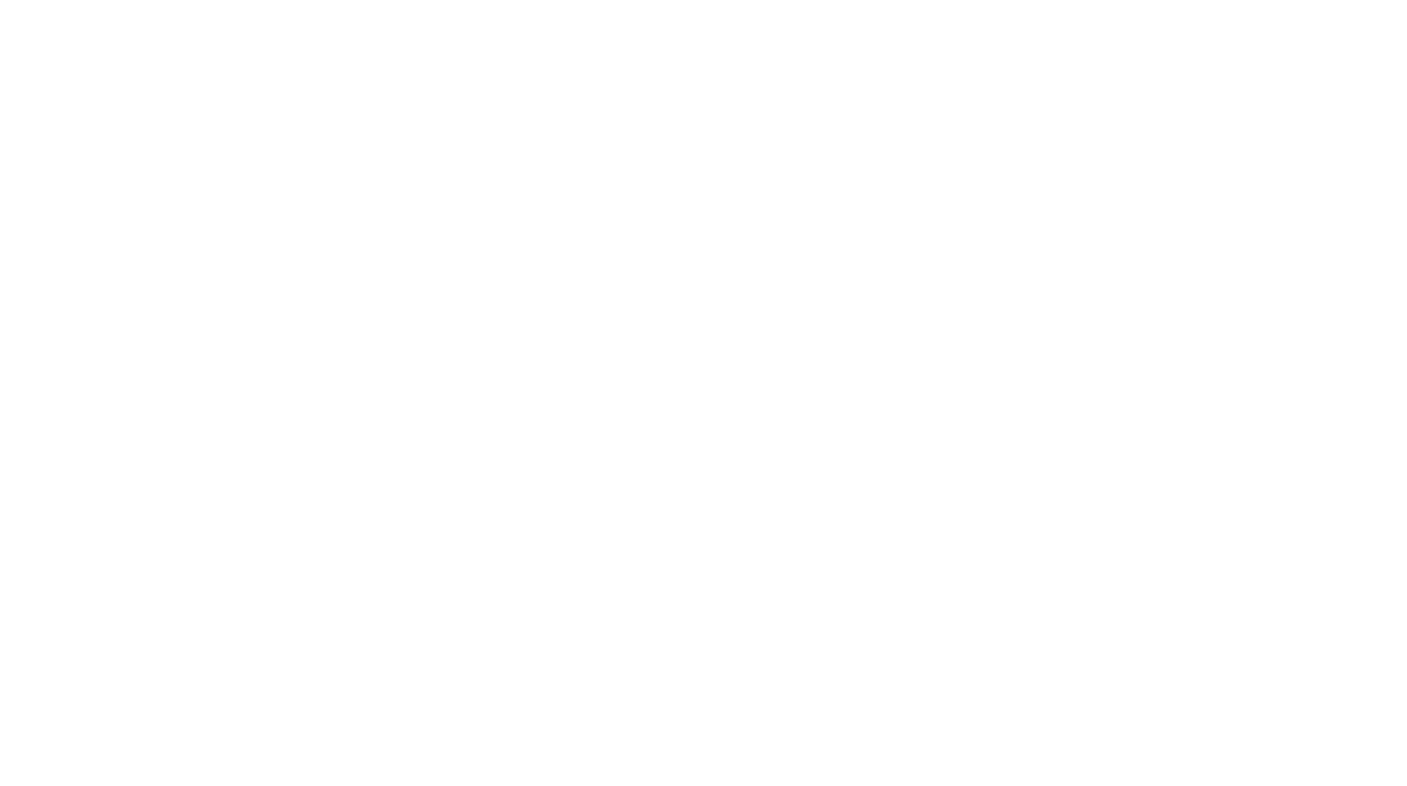

In [6]:
interact(update_plot,
         t=FloatSlider(min=t_min, max=t_max, step=0.05, value=0.5, description='Параметр $t$'),
         reverse={'Прямое (P₁→P₂)': False, 'Обратное (P₂→P₁)': True})

---
## Задание №2. Векторы и комплексные числа

**Теория:** единичный вектор под углом $\theta$: $\mathbf{v} = (\cos\theta, \sin\theta)$. Комплексное число: $z = e^{i\theta} = \cos\theta + i\sin\theta$.

**Задачи:**
- Пусть даны два вектора 𝐚 = (
𝑎𝑥
𝑎𝑦
) и 𝐛 = (
𝑏𝑥
𝑏𝑦
), оба имеют единичную длину, вектор 𝐚
направлен под углом 10
°
 к оси 𝑂𝑥, а 𝐛 под углом 40
°
. Вычислите их компоненты. Что
делать в общем случае, когда мы хотим построить единичный вектор, направленный
под определенным углом?
- Нарисуйте векторы 𝐚 и 𝐛 как это показано на Рис. 2. В каком месте координатной плоскости вы будите их рисовать? Обязаны ли они быть отложены от одной точки?
- Вычислите площадь треугольника, построенного на векторах 𝐚 и 𝐛. Вычислите площадь
параллелограмма, построенного на тех же векторах. Вычислите ориентированные
площади треугольника и параллелограмма.
- Вычислите ориентированную площадь треугольника, построенного на векторах 𝐛 и 𝐚
(это не опечатка, дублирующая предыдущее задание).

- Задайте теперь не векторы 𝐚 и 𝐛, а два комплексных числа 𝑧1 = 𝑎𝑥 + 𝑎𝑦
𝑖 и 𝑧2 = 𝑏𝑥 + 𝑏𝑦
𝑖.
Как их отобразить на комплексной плоскости? Откуда их следует откладывать? Вычислите 𝑒
10
°
𝑖
 и 𝑒
40
°
𝑖
.

In [25]:
print("=" * 60)
print("Задание №2, пункт 1: Единичные векторы под углами 10° и 40°")
print("=" * 60)

# Углы в градусах
angle_a_deg = 10
angle_b_deg = 40

# Перевод в радианы
angle_a_rad = np.deg2rad(angle_a_deg)
angle_b_rad = np.deg2rad(angle_b_deg)

# Компоненты единичных векторов
a = np.array([np.cos(angle_a_rad), np.sin(angle_a_rad)])
b = np.array([np.cos(angle_b_rad), np.sin(angle_b_rad)])

print(f"Вектор a (угол {angle_a_deg}°):")
print(f"  a_x = cos({angle_a_deg}°) = {a[0]:.6f}")
print(f"  a_y = sin({angle_a_deg}°) = {a[1]:.6f}")
print(f"  |a| = {np.linalg.norm(a):.6f} (проверка)")

print(f"\nВектор b (угол {angle_b_deg}°):")
print(f"  b_x = cos({angle_b_deg}°) = {b[0]:.6f}")
print(f"  b_y = sin({angle_b_deg}°) = {b[1]:.6f}")
print(f"  |b| = {np.linalg.norm(b):.6f} (проверка)")

print("\n" + "=" * 60)
print("ОБЩИЙ СЛУЧАЙ:")
print("Единичный вектор под углом θ: v = (cos θ, sin θ)")
print("Для перевода градусов в радианы: rad = deg * π / 180")
print("=" * 60)

Задание №2, пункт 1: Единичные векторы под углами 10° и 40°
Вектор a (угол 10°):
  a_x = cos(10°) = 0.984808
  a_y = sin(10°) = 0.173648
  |a| = 1.000000 (проверка)

Вектор b (угол 40°):
  b_x = cos(40°) = 0.766044
  b_y = sin(40°) = 0.642788
  |b| = 1.000000 (проверка)

ОБЩИЙ СЛУЧАЙ:
Единичный вектор под углом θ: v = (cos θ, sin θ)
Для перевода градусов в радианы: rad = deg * π / 180


Задание №2, пункт 2: Визуализация векторов a и b
Векторы отложены от начала координат (0, 0)
Треугольник OAB — чёрный контур (без заливки)
Векторы a и b — чёрные, стрелки на концах



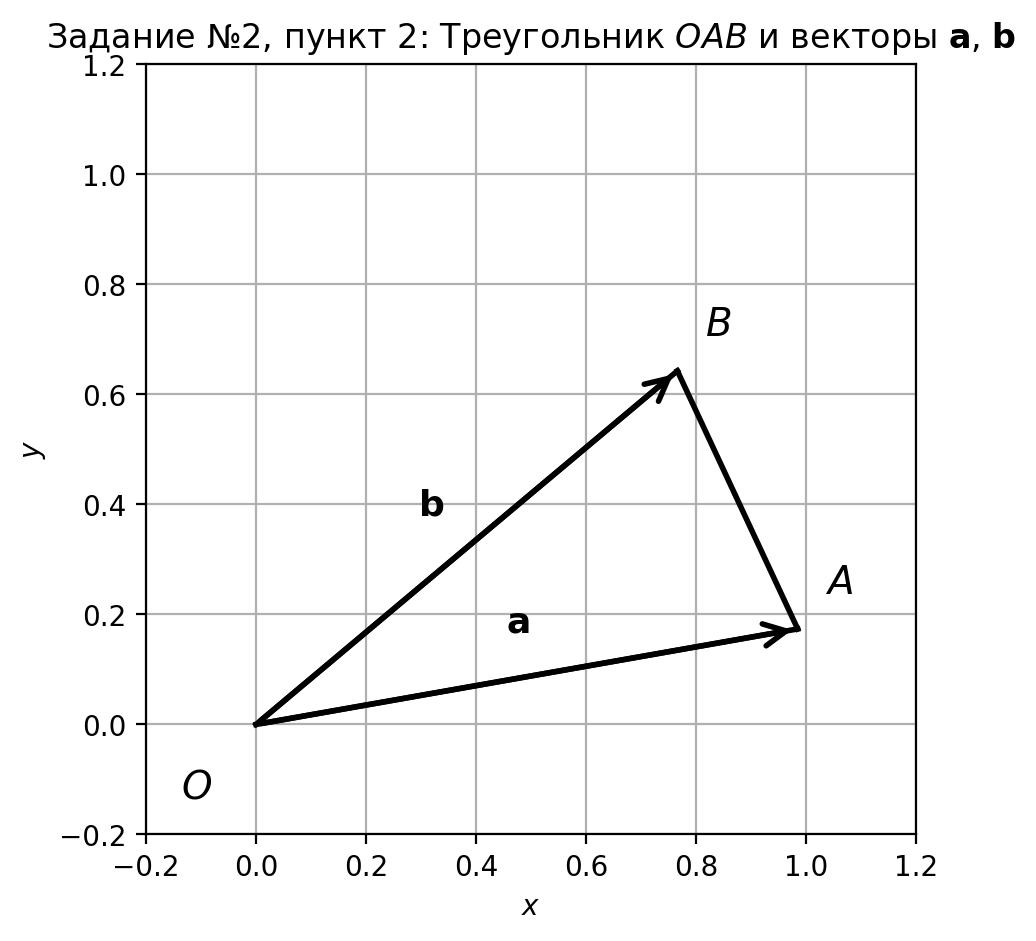

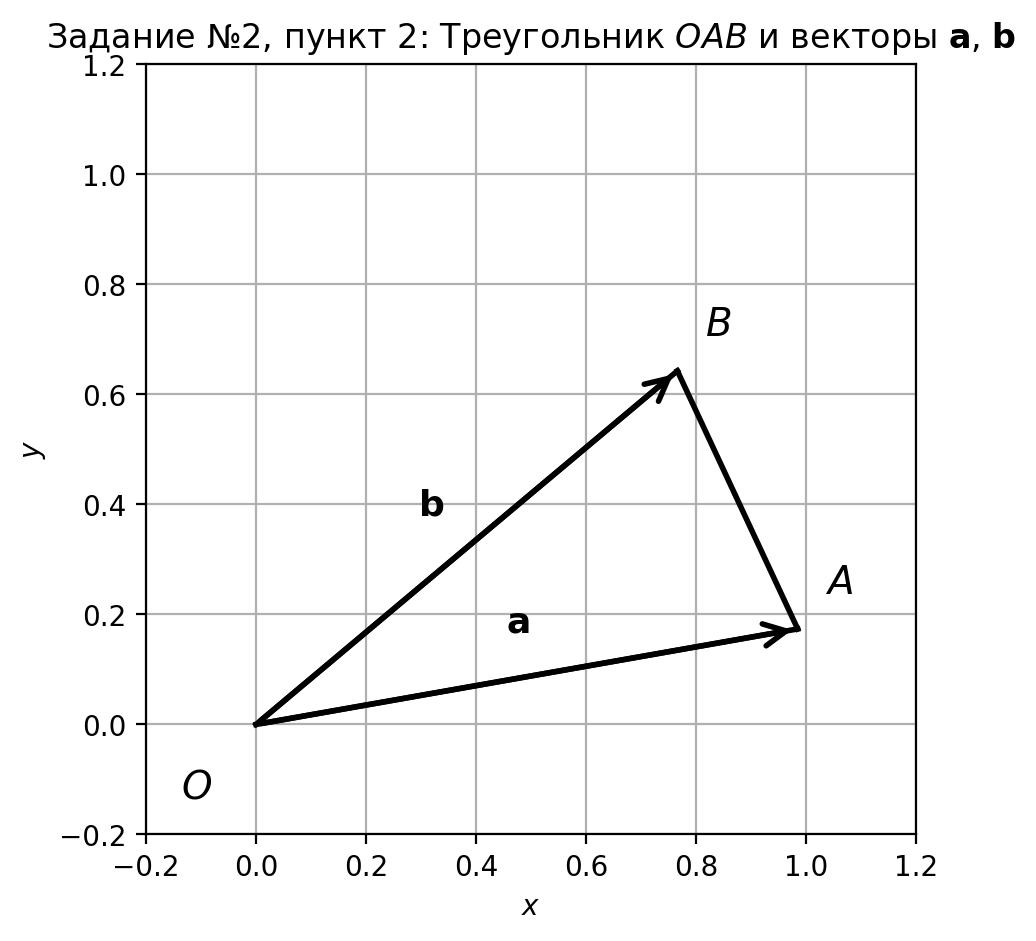

In [26]:
print("Задание №2, пункт 2: Визуализация векторов a и b")
print("Векторы отложены от начала координат (0, 0)")
print("Треугольник OAB — чёрный контур (без заливки)")
print("Векторы a и b — чёрные, стрелки на концах")
print()

fig = plt.figure(figsize=(5, 5), dpi=200)
ax = fig.add_subplot()

# 1. ЧЁРНЫЙ контур треугольника OAB (без заливки)
# Сторона OA (вектор a)
ax.plot([0, a[0]], [0, a[1]], 'k-', linewidth=2)
# Сторона OB (вектор b)
ax.plot([0, b[0]], [0, b[1]], 'k-', linewidth=2)
# Сторона AB (соединяет концы векторов)
ax.plot([a[0], b[0]], [a[1], b[1]], 'k-', linewidth=2)

# 2. Стрелки НА КОНЦАХ векторов (большие)
# Стрелка для вектора a (в конце)
ax.annotate('', xy=(a[0], a[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=20))
# Стрелка для вектора b (в конце)
ax.annotate('', xy=(b[0], b[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=20))

# 3. Подписи вершин треугольника (смещены, чтобы не перекрывать линии)
ax.text(-0.08, -0.08, '$O$', fontsize=14, fontweight='bold', ha='right', va='top')
ax.text(a[0] + 0.05, a[1] + 0.05, '$A$', fontsize=14, fontweight='bold', ha='left', va='bottom')
ax.text(b[0] + 0.05, b[1] + 0.05, '$B$', fontsize=14, fontweight='bold', ha='left', va='bottom')

# 4. Подписи векторов (посередине, с небольшим смещением перпендикулярно)
# Для вектора a
mid_a = a / 2
offset_a = np.array([-a[1], a[0]]) * 0.1  # перпендикулярное смещение
ax.text(mid_a[0] + offset_a[0], mid_a[1] + offset_a[1], 
        '$\\mathbf{a}$', fontsize=13, fontweight='bold', ha='center', va='center')

# Для вектора b
mid_b = b / 2
offset_b = np.array([-b[1], b[0]]) * 0.1
ax.text(mid_b[0] + offset_b[0], mid_b[1] + offset_b[1], 
        '$\\mathbf{b}$', fontsize=13, fontweight='bold', ha='center', va='center')

# 5. Оформление
ax.grid(True)
ax.set_aspect('equal')
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Задание №2, пункт 2: Треугольник $OAB$ и векторы $\\mathbf{a}$, $\\mathbf{b}$')

display(fig)

In [27]:
print("=" * 60)
print("Задание №2, пункт 3: Вычисление площадей")
print("=" * 60)

# Определитель (ориентированная площадь параллелограмма)
det_ab = a[0] * b[1] - a[1] * b[0]

# Абсолютные площади
area_parallelogram_abs = abs(det_ab)
area_triangle_abs = area_parallelogram_abs / 2

# Ориентированные площади
area_parallelogram_oriented = det_ab
area_triangle_oriented = det_ab / 2

print(f"Определитель det(a, b) = a_x·b_y - a_y·b_x = {det_ab:.6f}")
print()
print("ПЛОЩАДИ (абсолютные):")
print(f"  Площадь параллелограмма: |det(a, b)| = {area_parallelogram_abs:.6f}")
print(f"  Площадь треугольника: |det(a, b)|/2 = {area_triangle_abs:.6f}")
print()
print("ОРИЕНТИРОВАННЫЕ ПЛОЩАДИ (со знаком):")
print(f"  Параллелограмм: S_± = det(a, b) = {area_parallelogram_oriented:.6f}")
print(f"  Треугольник: S_± = det(a, b)/2 = {area_triangle_oriented:.6f}")
print()
print("ГЕОМЕТРИЧЕСКИЙ СМЫСЛ:")
print("  det(a, b) > 0  → поворот от a к b против часовой стрелки")
print("  det(a, b) < 0  → поворот от a к b по часовой стрелке")
print("=" * 60)

Задание №2, пункт 3: Вычисление площадей
Определитель det(a, b) = a_x·b_y - a_y·b_x = 0.500000

ПЛОЩАДИ (абсолютные):
  Площадь параллелограмма: |det(a, b)| = 0.500000
  Площадь треугольника: |det(a, b)|/2 = 0.250000

ОРИЕНТИРОВАННЫЕ ПЛОЩАДИ (со знаком):
  Параллелограмм: S_± = det(a, b) = 0.500000
  Треугольник: S_± = det(a, b)/2 = 0.250000

ГЕОМЕТРИЧЕСКИЙ СМЫСЛ:
  det(a, b) > 0  → поворот от a к b против часовой стрелки
  det(a, b) < 0  → поворот от a к b по часовой стрелке


In [28]:
print("=" * 60)
print("Задание №2, пункт 4: Ориентированная площадь для (b, a)")
print("=" * 60)

det_ba = b[0] * a[1] - b[1] * a[0]

print(f"det(b, a) = b_x·a_y - b_y·a_x = {det_ba:.6f}")
print(f"Ориентированная площадь параллелограмма (b, a): {det_ba:.6f}")
print(f"Ориентированная площадь треугольника (b, a): {det_ba/2:.6f}")
print()
print("СВОЙСТВО: det(b, a) = -det(a, b)")
print(f"Проверка: det(b, a) = {det_ba:.6f}, -det(a, b) = {-det_ab:.6f}")
print("=" * 60)

Задание №2, пункт 4: Ориентированная площадь для (b, a)
det(b, a) = b_x·a_y - b_y·a_x = -0.500000
Ориентированная площадь параллелограмма (b, a): -0.500000
Ориентированная площадь треугольника (b, a): -0.250000

СВОЙСТВО: det(b, a) = -det(a, b)
Проверка: det(b, a) = -0.500000, -det(a, b) = -0.500000


Задание №2, пункт 5: Комплексные числа
ИЗ ВЕКТОРОВ:
  z₁ = a_x + i·a_y = 0.984808 + 0.173648i
  z₂ = b_x + i·b_y = 0.766044 + 0.642788i

ПО ФОРМУЛЕ ЭЙЛЕРА (e^(i·θ) = cos θ + i·sin θ):
  e^{10°i} = cos(10°) + i·sin(10°) = 0.984808 + 0.173648i
  e^{40°i} = cos(40°) + i·sin(40°) = 0.766044 + 0.642788i

ОТОБРАЖЕНИЕ НА КОМПЛЕКСНОЙ ПЛОСКОСТИ:
  - Действительная часть (Re) → ось x
  - Мнимая часть (Im) → ось y
  - Комплексные числа откладываются из начала координат (0, 0)


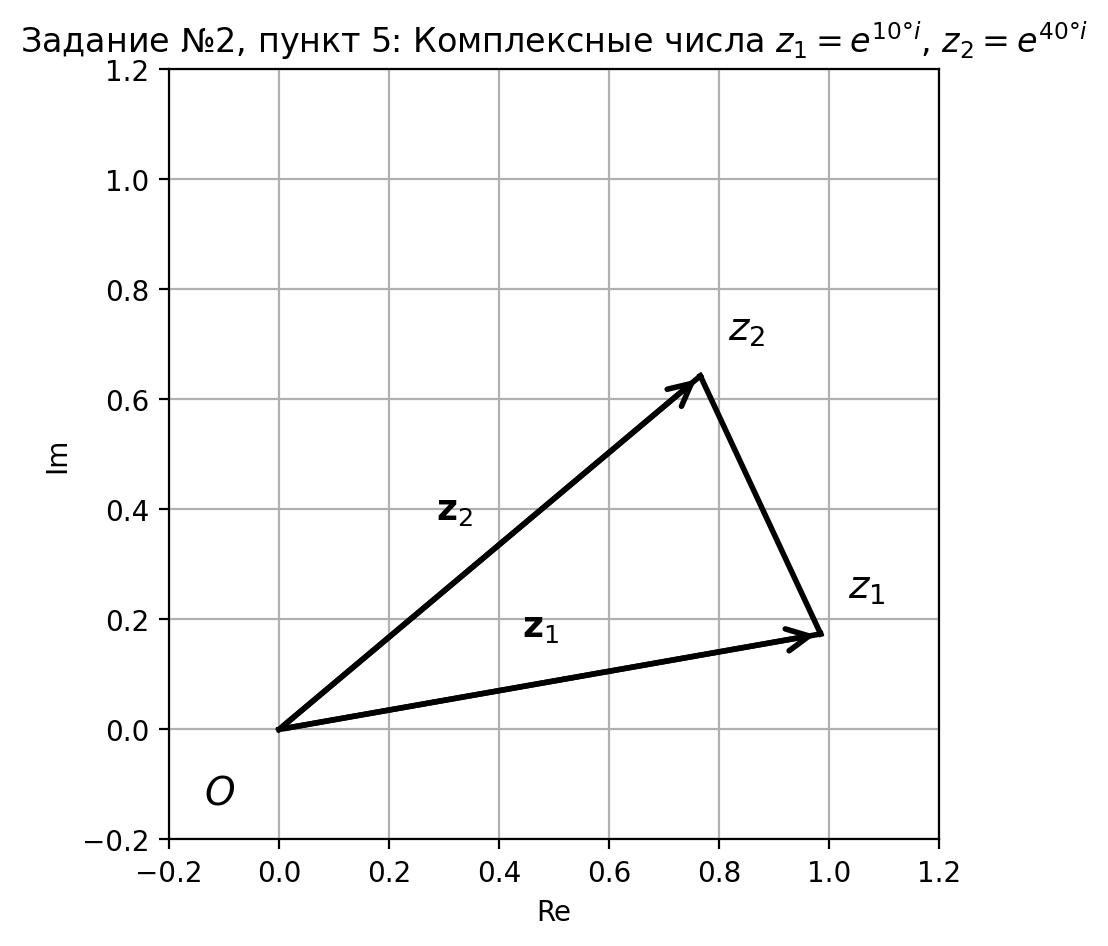

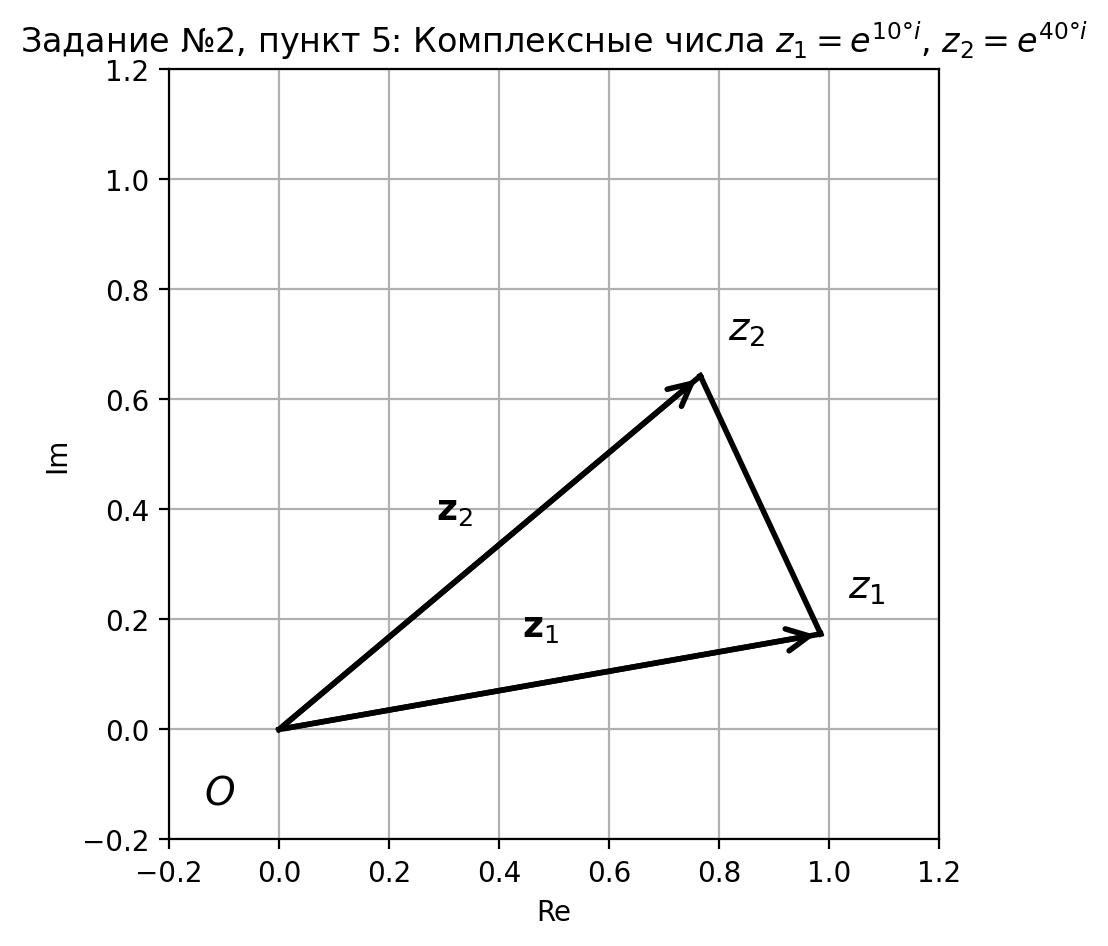

In [29]:
print("=" * 60)
print("Задание №2, пункт 5: Комплексные числа")
print("=" * 60)

# Комплексные числа
z1 = a[0] + a[1] * 1j
z2 = b[0] + b[1] * 1j

print("ИЗ ВЕКТОРОВ:")
print(f"  z₁ = a_x + i·a_y = {z1.real:.6f} + {z1.imag:.6f}i")
print(f"  z₂ = b_x + i·b_y = {z2.real:.6f} + {z2.imag:.6f}i")
print()
print("ПО ФОРМУЛЕ ЭЙЛЕРА (e^(i·θ) = cos θ + i·sin θ):")
print(f"  e^{{{angle_a_deg}°i}} = cos({angle_a_deg}°) + i·sin({angle_a_deg}°) = {np.cos(angle_a_rad):.6f} + {np.sin(angle_a_rad):.6f}i")
print(f"  e^{{{angle_b_deg}°i}} = cos({angle_b_deg}°) + i·sin({angle_b_deg}°) = {np.cos(angle_b_rad):.6f} + {np.sin(angle_b_rad):.6f}i")
print()
print("ОТОБРАЖЕНИЕ НА КОМПЛЕКСНОЙ ПЛОСКОСТИ:")
print("  - Действительная часть (Re) → ось x")
print("  - Мнимая часть (Im) → ось y")
print("  - Комплексные числа откладываются из начала координат (0, 0)")
print("=" * 60)

# Визуализация комплексных чисел (аналогично пункту 2)
fig = plt.figure(figsize=(5, 5), dpi=200)
ax = fig.add_subplot()

# 1. ЧЁРНЫЙ контур треугольника (как в пункте 2)
ax.plot([0, z1.real], [0, z1.imag], 'k-', linewidth=2)
ax.plot([0, z2.real], [0, z2.imag], 'k-', linewidth=2)
ax.plot([z1.real, z2.real], [z1.imag, z2.imag], 'k-', linewidth=2)

# 2. Стрелки на концах векторов
ax.annotate('', xy=(z1.real, z1.imag), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=20))
ax.annotate('', xy=(z2.real, z2.imag), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=20))

# 3. Подписи точек
ax.text(-0.08, -0.08, '$O$', fontsize=14, fontweight='bold', ha='right', va='top')
ax.text(z1.real + 0.05, z1.imag + 0.05, '$z_1$', fontsize=14, fontweight='bold', ha='left', va='bottom')
ax.text(z2.real + 0.05, z2.imag + 0.05, '$z_2$', fontsize=14, fontweight='bold', ha='left', va='bottom')

# 4. Подписи векторов (посередине)
mid_z1 = np.array([z1.real, z1.imag]) / 2
offset_z1 = np.array([-z1.imag, z1.real]) * 0.1
ax.text(mid_z1[0] + offset_z1[0], mid_z1[1] + offset_z1[1], 
        '$\\mathbf{z}_1$', fontsize=13, fontweight='bold', ha='center', va='center')

mid_z2 = np.array([z2.real, z2.imag]) / 2
offset_z2 = np.array([-z2.imag, z2.real]) * 0.1
ax.text(mid_z2[0] + offset_z2[0], mid_z2[1] + offset_z2[1], 
        '$\\mathbf{z}_2$', fontsize=13, fontweight='bold', ha='center', va='center')

# 5. Оформление
ax.grid(True)
ax.set_aspect('equal')
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Задание №2, пункт 5: Комплексные числа $z_1 = e^{10°i}$, $z_2 = e^{40°i}$')

display(fig)

---
## Задание №3. Прямая и её угол наклона

**Теория:** В предыдущем задании вы должны были научиться задавать вектор, направленный
под определенным углом к оси 𝑂𝑥. Такой вектор можно использовать, чтобы отобразить
прямую для которой он будет служить направляющим вектором. Для этого следует
использовать формулу
𝐩(𝑡) = 𝐩0 + 𝐯𝑡,
где 𝐩0
 — некоторая точка прямой, а 𝐯 — направляющий вектор прямой
 

**Задачи:**
- Используйте вышеуказанную формулу для отображения прямой. Для этого вам нужно
вычислить хотя бы две точки прямой и соединить их отрезком. Точки должны отстоять
друг от друга на такое расстояние, чтобы рисунок получился наглядным.
- Создать ползунок, который будет управлять направлением вектора 𝐯 в градусах.
Отобразить прямую и двигая ползунок изменять ее наклон. Прямая всегда должна
отображаться как бесконечная прямая, а не как отрезок то есть при любом размере
координатной плоскости оба конца прямой должны упираться в границу картинки.
- Вручную реализовать требования предыдущего пункта довольно тяжело. Поэтому в
Matplotlib существует функция axline для отображения бесконечной прямой. Выяснить и уметь объяснить математический смысл всех аргументов данной функции.
Задать угол наклона прямой (в градусах) с помощью ползунка. Отобразить прямую
теперь уже только с помощью axline и менять ее наклон ползунком также как и в предыдущем пункте с шагом в 1°


Задание №3, пункты 1-2: Прямая через параметрическое уравнение
Формула: p(t) = p₀ + v·t, где v = (cos θ, sin θ)


interactive(children=(IntSlider(value=10, description='Угол (°)', max=180, min=-180), Output()), _dom_classes=…

<function __main__.line_by_points(angle_deg=10)>

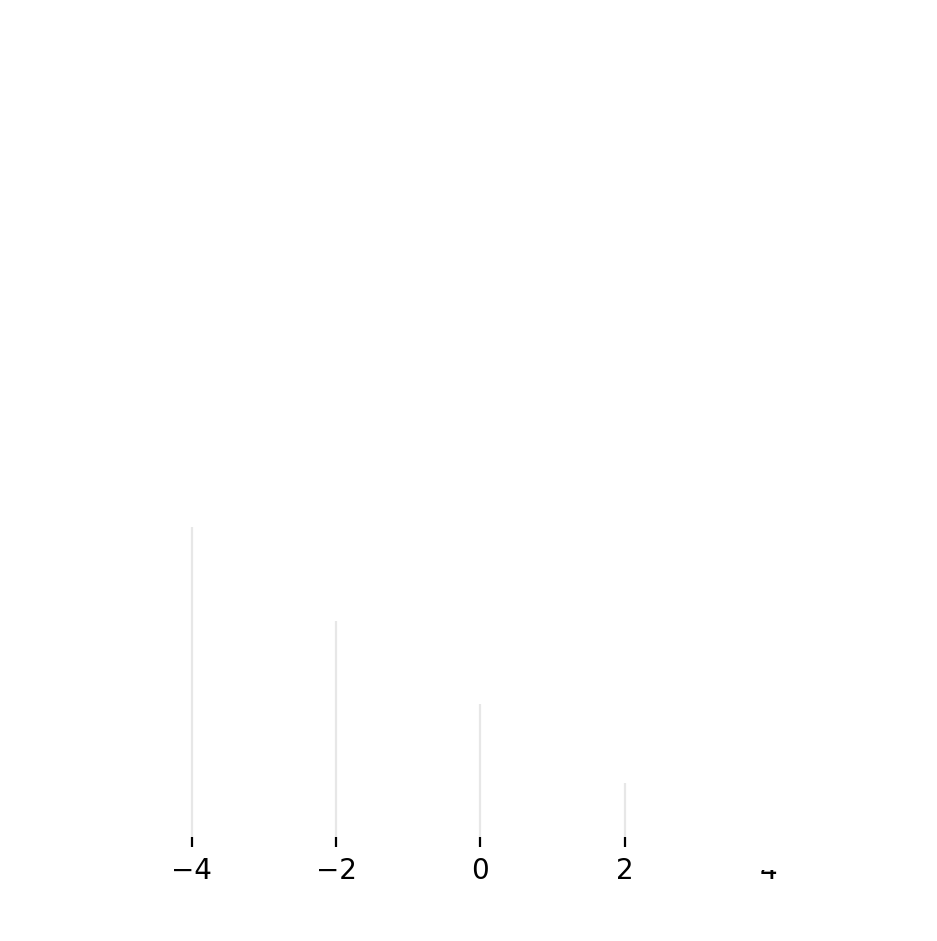

In [30]:
print("=" * 60)
print("Задание №3, пункты 1-2: Прямая через параметрическое уравнение")
print("Формула: p(t) = p₀ + v·t, где v = (cos θ, sin θ)")
print("=" * 60)

def line_by_points(angle_deg=10):
    # Угол в радианы
    angle_rad = np.deg2rad(angle_deg)
    
    # Направляющий вектор (единичный)
    v = np.array([np.cos(angle_rad), np.sin(angle_rad)])
    
    # Опорная точка (проходит через начало координат)
    p0 = np.array([0, 0])
    
    # Вычисляем две точки для отображения (уходят далеко за пределы)
    t1 = -10
    t2 = 10
    
    p1 = p0 + v * t1
    p2 = p0 + v * t2
    
    fig = plt.figure(figsize=(5, 5), dpi=200)
    ax = fig.add_subplot()
    
    # Рисуем прямую (синяя линия)
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b-', linewidth=2, label=f'Прямая (угол {angle_deg}°)')
    
    # ОСИ X и Y (чёрные прямые, проходящие через начало координат)
    ax.axhline(y=0, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
    ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
    
    # Подписи осей
    ax.text(5.2, -0.3, '$x$', fontsize=13, fontweight='bold', ha='center')
    ax.text(-0.3, 5.2, '$y$', fontsize=13, fontweight='bold', ha='center')
    
    # Деления на осях
    # Для оси X (цифры ВЫШЕ, чем обычно)
    for x_val in range(-5, 6):
        if x_val != 0:
            ax.plot(x_val, 0, 'k|', markersize=8, markeredgewidth=1.5)
            ax.text(x_val, 0.15, f'{x_val}', fontsize=9, ha='center')  # y = 0.15 (выше)
    
    # Для оси Y (цифры ПРАВЕЕ, чем обычно)
    for y_val in range(-5, 6):
        if y_val != 0:
            ax.plot(0, y_val, '_k', markersize=8, markeredgewidth=1.5)
            ax.text(0.15, y_val, f'{y_val}', fontsize=9, va='center')  # x = 0.15 (правее)
    
    # Ноль в начале координат (чуть смещён)
    ax.text(-0.25, -0.25, '0', fontsize=11, fontweight='bold', ha='right', va='top')
    
    # Оформление
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'Прямая под углом {angle_deg}° к оси $Ox$')
    ax.legend(loc='upper left')
    
    display(fig)

interact(line_by_points, angle_deg=IntSlider(min=-180, max=180, step=1, value=10, description='Угол (°)'))

Задание №3, пункт 3: Прямая через axline
axline(point, slope=k) — бесконечная прямая через point с угловым коэффициентом k
Математический смысл: k = tg(θ) = sin θ / cos θ


interactive(children=(IntSlider(value=10, description='Угол (°)', max=180, min=-180), Output()), _dom_classes=…

<function __main__.line_by_axline(angle_deg=10)>

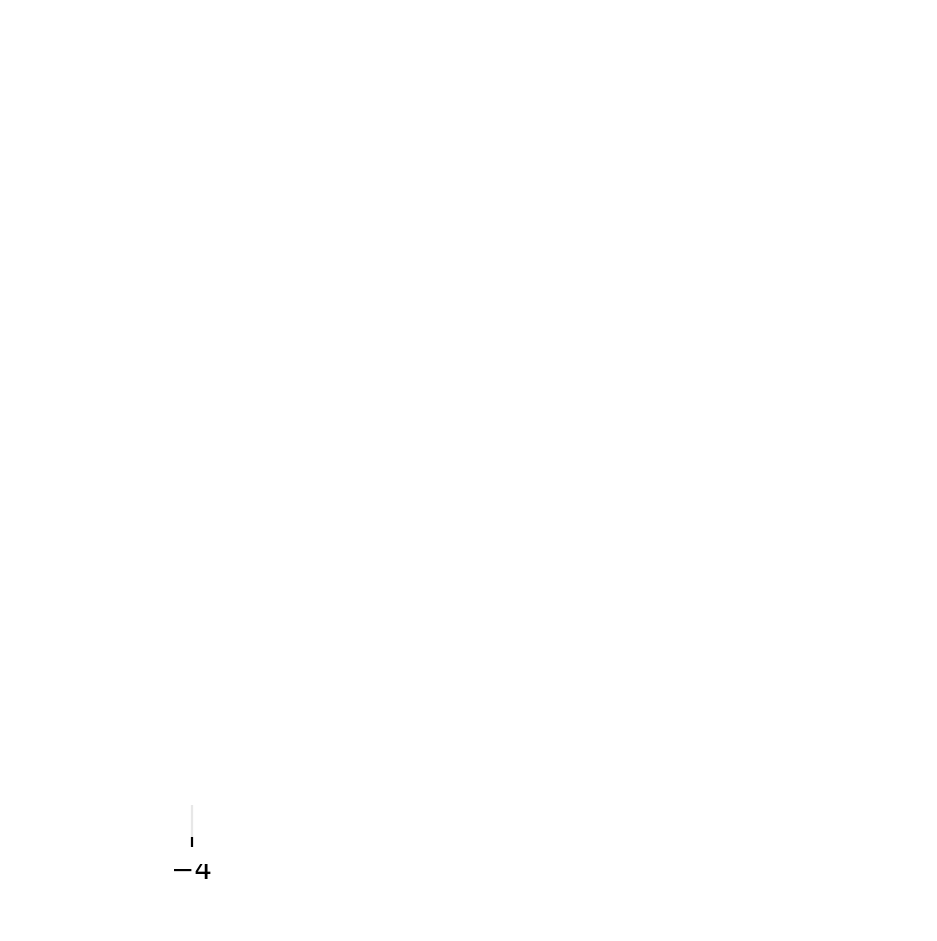

In [31]:
print("=" * 60)
print("Задание №3, пункт 3: Прямая через axline")
print("axline(point, slope=k) — бесконечная прямая через point с угловым коэффициентом k")
print("Математический смысл: k = tg(θ) = sin θ / cos θ")
print("=" * 60)

def line_by_axline(angle_deg=10):
    angle_rad = np.deg2rad(angle_deg)
    
    fig = plt.figure(figsize=(5, 5), dpi=200)
    ax = fig.add_subplot()
    
    # ========== ОСИ X и Y (такое же оформление, как в пункте 2) ==========
    # Оси (чёрные линии)
    ax.axhline(y=0, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
    ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-', alpha=0.8)
    
    # Подписи осей
    ax.text(5.2, -0.3, '$x$', fontsize=13, fontweight='bold', ha='center')
    ax.text(-0.3, 5.2, '$y$', fontsize=13, fontweight='bold', ha='center')
    
    # Деления на оси X (цифры ВЫШЕ)
    for x_val in range(-5, 6):
        if x_val != 0:
            ax.plot(x_val, 0, 'k|', markersize=8, markeredgewidth=1.5)
            ax.text(x_val, 0.15, f'{x_val}', fontsize=9, ha='center')
    
    # Деления на оси Y (цифры ПРАВЕЕ)
    for y_val in range(-5, 6):
        if y_val != 0:
            ax.plot(0, y_val, '_k', markersize=8, markeredgewidth=1.5)
            ax.text(0.15, y_val, f'{y_val}', fontsize=9, va='center')
    
    # Ноль в начале координат
    ax.text(-0.25, -0.25, '0', fontsize=11, fontweight='bold', ha='right', va='top')
    # ====================================================================
    
    # Рисуем прямую через axline (синяя)
    if angle_deg % 180 == 90 or angle_deg % 180 == -90:
        ax.axvline(x=0, color='blue', linewidth=2, label=f'Прямая (угол {angle_deg}°)')
    else:
        k = np.tan(angle_rad)
        ax.axline((0, 0), slope=k, color='blue', linewidth=2, label=f'Прямая (угол {angle_deg}°)')
    
    # Оформление
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'Прямая под углом {angle_deg}° к оси $Ox$ (axline)')
    ax.legend(loc='upper left')
    
    display(fig)

interact(line_by_axline, angle_deg=IntSlider(min=-180, max=180, step=1, value=10, description='Угол (°)'))

---
## Задание №4. Окружность — циферблат часов

**Теория:** параметрическое уравнение окружности: $x = R\cos t$, $y = R\sin t$.

**Задачи:**
-Нарисуйте без заливки цветом окружность с центром в точке O, радиуса 𝑅 = 1 с помощью примитива Circle из модуля patches.
- Отобразите радиус окружности в виде стрелки или в виде отрезка.
- Создайте ползунок, который будет вращать радиус окружности по часовой стрелке с
шагом в 1
°
. По периметру окружности проставьте цифры циферблата часов, как это
показано на Рис. 4.
- Используйте параметрическое уравнение окружности $$\mathbf{p}(t) = \begin{bmatrix} R \cos t \\ R \sin t \end{bmatrix} \quad \Leftrightarrow \quad \begin{cases} x(t) = R \cos t \\ y(t) = R \sin t \end{cases}$$ для того, чтобы нарисовать цифры в нужных местах окружности.



Задание №4: Циферблат часов
Окружность радиуса R=1, стрелка-радиус, цифры часов (1-12)
Стрелка вращается ПО ЧАСОВОЙ СТРЕЛКЕ с шагом 1°


interactive(children=(IntSlider(value=0, description='Угол (°)', max=360), Output()), _dom_classes=('widget-in…

<function __main__.draw_clock(angle_deg=0)>

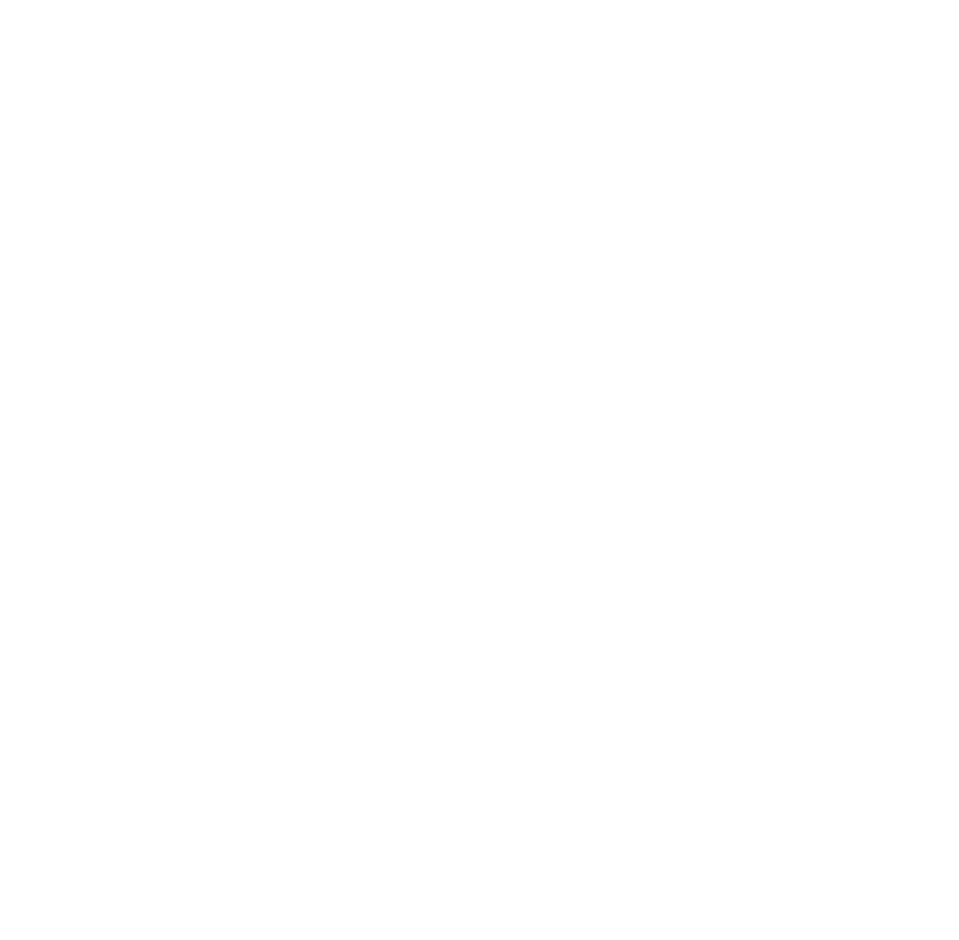

In [42]:
print("=" * 60)
print("Задание №4: Циферблат часов")
print("Окружность радиуса R=1, стрелка-радиус, цифры часов (1-12)")
print("Стрелка вращается ПО ЧАСОВОЙ СТРЕЛКЕ с шагом 1°")
print("=" * 60)

# Параметры
R = 1.0  # радиус окружности
center = (0, 0)  # центр окружности

def draw_clock(angle_deg=0):
    """
    angle_deg — угол поворота стрелки в градусах
    angle_deg = 0° → стрелка на 12 часов (вверх)
    angle_deg = 90° → стрелка на 3 часа (вправо)
    angle_deg = 180° → стрелка на 6 часов (вниз)
    angle_deg = 270° → стрелка на 9 часов (влево)
    """
    fig = plt.figure(figsize=(5, 5), dpi=200)
    ax = fig.add_subplot()
    
    # 1. Окружность (без заливки)
    circle = patches.Circle(center, radius=R, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(circle)
    
    # 2. Оси координат (для наглядности)
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='black', linewidth=0.8, alpha=0.5)
    
    # 3. Угол для стрелки (в радианы)
    # angle_deg = 0° → 12 часов (вверх) = 90° в стандартной математике
    # angle_deg = 90° → 3 часа (вправо) = 0° в стандартной математике
    math_angle_deg = 90 - angle_deg
    math_angle_rad = np.deg2rad(math_angle_deg)
    
    # Конец стрелки (на окружности)
    x_end = R * np.cos(math_angle_rad)
    y_end = R * np.sin(math_angle_rad)
    
    # 4. Стрелка-радиус (от центра до окружности)
    ax.annotate('', xy=(x_end, y_end), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2, mutation_scale=15))
    
    # 5. Цифры циферблата (1-12) по периметру окружности
    for hour in range(1, 13):
        # Угол для цифры (12 часов = 90°, 3 часа = 0°)
        ang_deg_hour = 90 - hour * 30
        ang_rad_hour = np.deg2rad(ang_deg_hour)
        
        # Координаты цифры (чуть дальше окружности)
        x_num = (R + 0.15) * np.cos(ang_rad_hour)
        y_num = (R + 0.15) * np.sin(ang_rad_hour)
        
        # Маленькая точка на окружности
        ax.plot(R * np.cos(ang_rad_hour), R * np.sin(ang_rad_hour), 'ko', markersize=3)
        
        # Подпись цифры
        ax.text(x_num, y_num, str(hour), fontsize=12, ha='center', va='center', fontweight='bold')
    
    # 6. Вычисление текущего часа по углу
    # angle_deg = 0° → 12 часов
    # angle_deg = 30° → 1 час
    # angle_deg = 60° → 2 часа
    # angle_deg = 90° → 3 часа
    # Формула: hour = (angle_deg / 30) + 12, затем берём остаток от деления на 12
    hour_display = int((angle_deg / 30) + 12) % 12
    if hour_display == 0:
        hour_display = 12
    
    # 7. Оформление
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'Циферблат часов — стрелка на {hour_display} ч. (угол {angle_deg}°)')
    
    display(fig)

# Ползунок для угла (0° до 360°, шаг 1°)
interact(draw_clock, angle_deg=IntSlider(min=0, max=360, step=1, value=0, description='Угол (°)'))

In [39]:
print("=" * 60)
print("Задание №4: ПОЯСНЕНИЯ ДЛЯ ЗАЩИТЫ")
print("=" * 60)
print()
print("1. Окружность:")
print("   - patches.Circle(center, radius=R, fill=False)")
print()
print("2. Стрелка-радиус:")
print("   - От центра (0,0) до точки на окружности")
print("   - Параметрическое уравнение: x = R·cos(θ), y = R·sin(θ)")
print("   - Ползунок меняет угол θ от 0° до 360° с шагом 1°")
print("   - Вращение по часовой стрелке: увеличение угла = поворот по часовой?")
print("     В формуле: 0° = 3 часа, 90° = 12 часов, 180° = 9 часов")
print()
print("3. Цифры циферблата:")
print("   - Размещены по параметрическому уравнению окружности")
print("   - Угол для часа h: θ = 90° - h·30°")
print("   - Координаты: x = (R + 0.15)·cos(θ), y = (R + 0.15)·sin(θ)")
print()
print("4. Параметрическое уравнение окружности:")
print("   x(t) = R·cos(t), y(t) = R·sin(t), t ∈ [0, 2π)")
print("   Используется для стрелки и для цифр")
print()
print("5. Ползунок:")
print("   - IntSlider(min=0, max=360, step=1)")
print("   - Позволяет вращать стрелку на 1° за шаг")
print("   - По часовой стрелке: увеличение угла (условно)")
print("=" * 60)

Задание №4: ПОЯСНЕНИЯ ДЛЯ ЗАЩИТЫ

1. Окружность:
   - patches.Circle(center, radius=R, fill=False)

2. Стрелка-радиус:
   - От центра (0,0) до точки на окружности
   - Параметрическое уравнение: x = R·cos(θ), y = R·sin(θ)
   - Ползунок меняет угол θ от 0° до 360° с шагом 1°
   - Вращение по часовой стрелке: увеличение угла = поворот по часовой?
     В формуле: 0° = 3 часа, 90° = 12 часов, 180° = 9 часов

3. Цифры циферблата:
   - Размещены по параметрическому уравнению окружности
   - Угол для часа h: θ = 90° - h·30°
   - Координаты: x = (R + 0.15)·cos(θ), y = (R + 0.15)·sin(θ)

4. Параметрическое уравнение окружности:
   x(t) = R·cos(t), y(t) = R·sin(t), t ∈ [0, 2π)
   Используется для стрелки и для цифр

5. Ползунок:
   - IntSlider(min=0, max=360, step=1)
   - Позволяет вращать стрелку на 1° за шаг
   - По часовой стрелке: увеличение угла (условно)


---
## Задание №5. Прямоугольник и матричные преобразования

**Теория:** матричное преобразование $\mathbf{p}' = A\mathbf{p}$. Ориентированная площадь многоугольника: $S = \frac{1}{2} \sum (x_i y_{i+1} - x_{i+1} y_i)$.

**Задачи:**
1. Нарисовать прямоугольник с центром в начале координат.
2. Применить матрицу $A = \begin{pmatrix}1 & 2 \\ 0 & 1\end{pmatrix}$.
3. Вычислить ориентированную площадь.
4. Применить матрицу $B = \begin{pmatrix}-1 & 0 \\ 0 & -1\end{pmatrix}$.

ПУНКТ 1: Прямоугольник (не квадрат) с помощью Polygon
Центр пересечения диагоналей — в начале координат (0,0)
Размеры: ширина = 4, высота = 2
Вершины (против часовой стрелки):
  0: (-2.0, -1.0)
  1: (2.0, -1.0)
  2: (2.0, 1.0)
  3: (-2.0, 1.0)


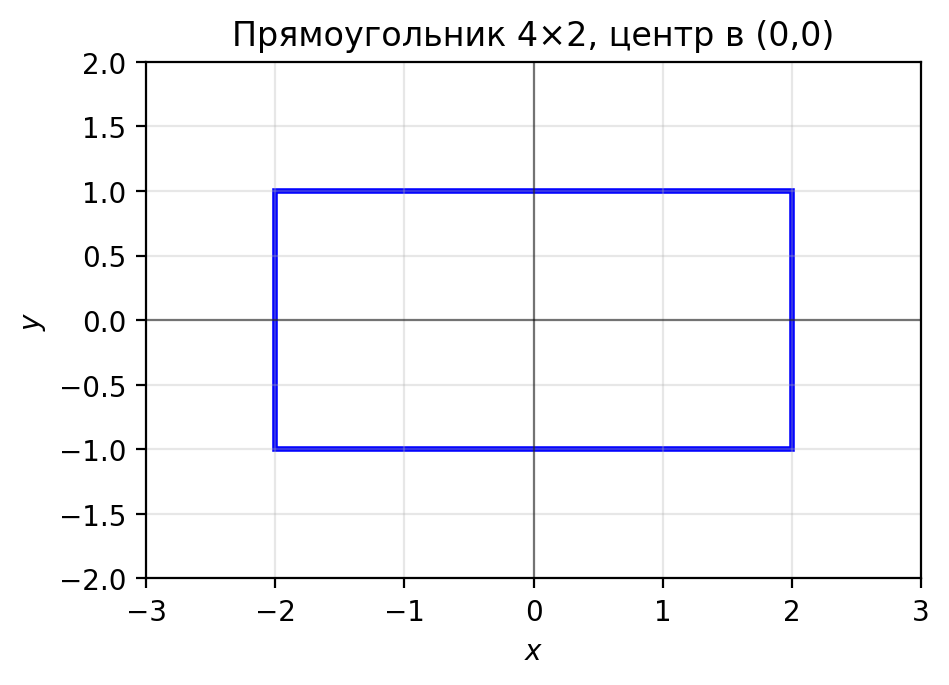

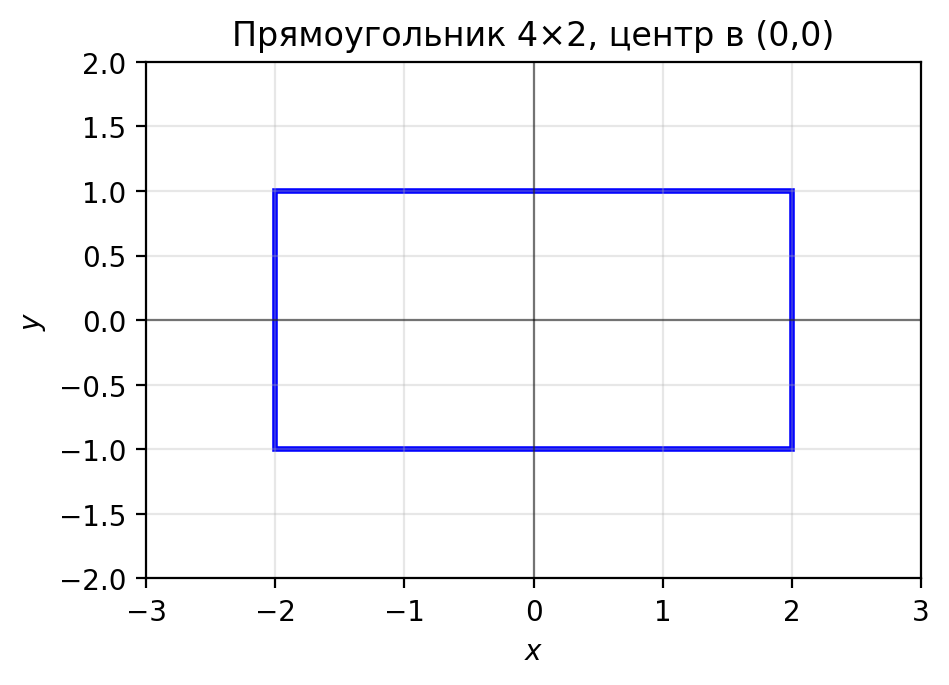

In [8]:
print("=" * 60)
print("ПУНКТ 1: Прямоугольник (не квадрат) с помощью Polygon")
print("Центр пересечения диагоналей — в начале координат (0,0)")
print("=" * 60)

width, height = 4, 2
rect = np.array([
    [-width/2, -height/2],
    [ width/2, -height/2],
    [ width/2,  height/2],
    [-width/2,  height/2]
])

print(f"Размеры: ширина = {width}, высота = {height}")
print(f"Вершины (против часовой стрелки):")
for i, v in enumerate(rect):
    print(f"  {i}: ({v[0]:.1f}, {v[1]:.1f})")

# Визуализация
fig1 = plt.figure(figsize=(5, 5), dpi=200)
ax1 = fig1.add_subplot()
ax1.add_patch(patches.Polygon(rect, fill=False, edgecolor='blue', linewidth=2))
ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_xlim(-3, 3)
ax1.set_ylim(-2, 2)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_title('Прямоугольник 4×2, центр в (0,0)')
display(fig1)

ПУНКТ 2: Умножение вершин на матрицу A = [[1, 1], [-1, 1]]
Матрица A:
[[ 1  1]
 [-1  1]]
Вершины после преобразования:
  0: (-3.0, 1.0)
  1: (1.0, -3.0)
  2: (3.0, -1.0)
  3: (-1.0, 3.0)


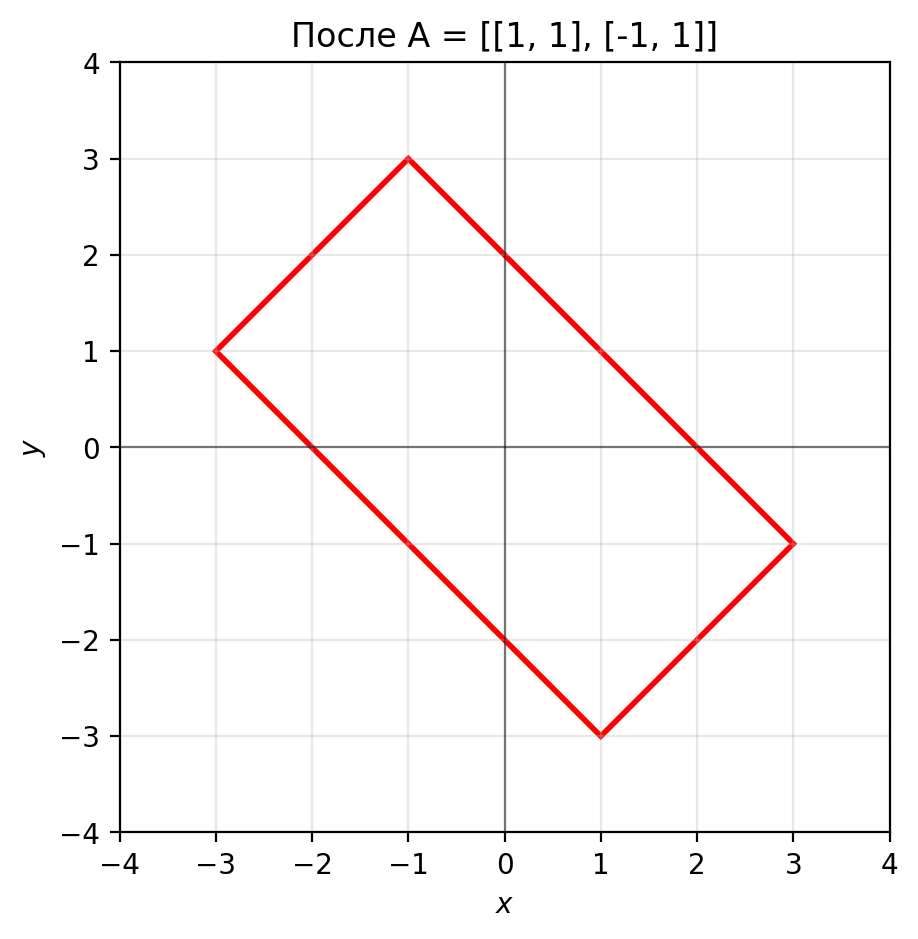

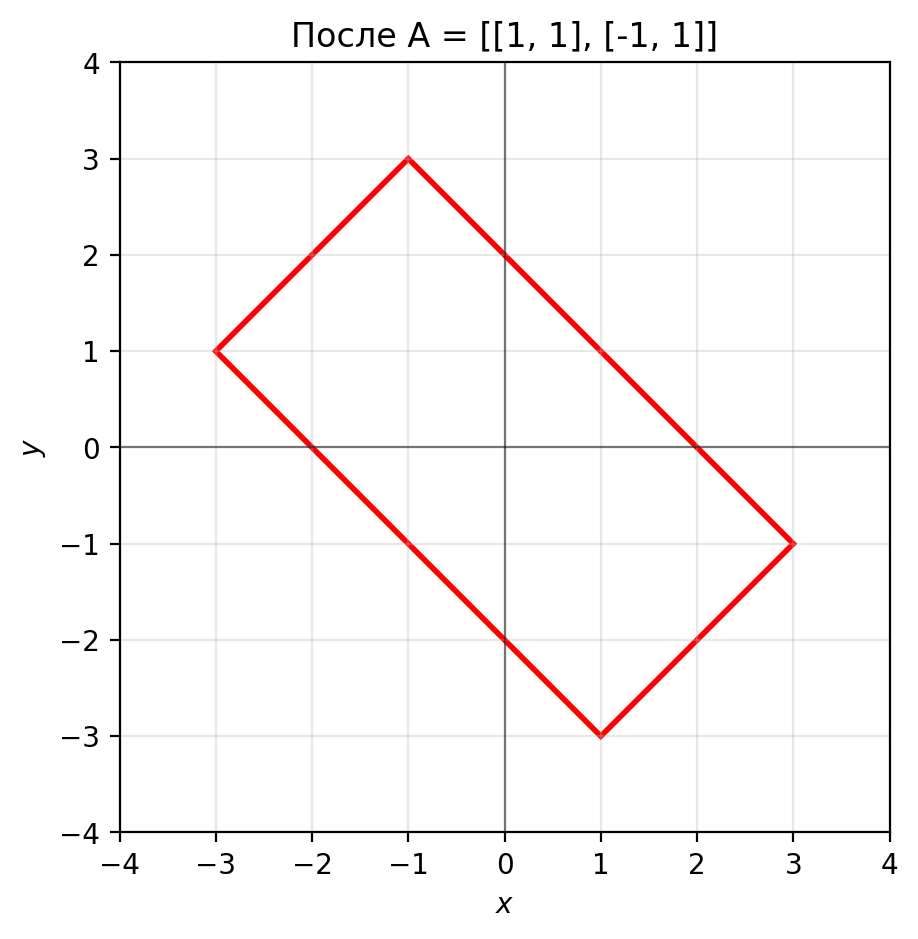

In [9]:
print("=" * 60)
print("ПУНКТ 2: Умножение вершин на матрицу A = [[1, 1], [-1, 1]]")
print("=" * 60)

A = np.array([[1, 1], [-1, 1]])
print(f"Матрица A:\n{A}")

# ИСПРАВЛЕНО: правильное умножение
rect_A = (A @ rect.T).T

print(f"Вершины после преобразования:")
for i, v in enumerate(rect_A):
    print(f"  {i}: ({v[0]:.1f}, {v[1]:.1f})")

# Визуализация
fig2 = plt.figure(figsize=(5, 5), dpi=200)
ax2 = fig2.add_subplot()
ax2.add_patch(patches.Polygon(rect_A, fill=False, edgecolor='red', linewidth=2))
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_title('После A = [[1, 1], [-1, 1]]')
display(fig2)

In [12]:
# Вывести координаты вершин
print("Вершины после A:")
print(rect_A)

print("\nВершины после B:")
print(rect_B)

# Проверить углы
v1_A = rect_A[1] - rect_A[0]
v2_A = rect_A[2] - rect_A[1]
dot_A = np.dot(v1_A, v2_A)
print(f"\nУгол после A (скалярное произведение): {dot_A}")

v1_B = rect_B[1] - rect_B[0]
v2_B = rect_B[2] - rect_B[1]
dot_B = np.dot(v1_B, v2_B)
print(f"Угол после B (скалярное произведение): {dot_B}")

Вершины после A:
[[-3.  1.]
 [ 1. -3.]
 [ 3. -1.]
 [-1.  3.]]

Вершины после B:
[[ 1. -3.]
 [-3.  1.]
 [-1.  3.]
 [ 3. -1.]]

Угол после A (скалярное произведение): 0.0
Угол после B (скалярное произведение): 0.0


In [10]:
print("=" * 60)
print("ПУНКТ 3: Ориентированная площадь исходного прямоугольника")
print("=" * 60)

def oriented_area(vertices):
    """Вершины НЕ замыкаются (последняя точка не повторяет первую)"""
    x = vertices[:, 0]
    y = vertices[:, 1]
    n = len(vertices)
    s = 0
    for i in range(n):
        s += x[i] * y[(i+1) % n] - x[(i+1) % n] * y[i]
    return 0.5 * s

area_original = oriented_area(rect)
print(f"Ориентированная площадь исходного прямоугольника: {area_original:.1f}")
print()
print("ОТВЕТ: Чтобы ориентированная площадь имела положительный знак,")
print("вершины нужно перечислять ПРОТИВ ЧАСОВОЙ СТРЕЛКИ.")
print(f"Площадь = {area_original:.1f} > 0 → порядок ПРОТИВ ЧАСОВОЙ СТРЕЛКИ")

ПУНКТ 3: Ориентированная площадь исходного прямоугольника
Ориентированная площадь исходного прямоугольника: 8.0

ОТВЕТ: Чтобы ориентированная площадь имела положительный знак,
вершины нужно перечислять ПРОТИВ ЧАСОВОЙ СТРЕЛКИ.
Площадь = 8.0 > 0 → порядок ПРОТИВ ЧАСОВОЙ СТРЕЛКИ


ПУНКТ 4: Умножение вершин на матрицу B = [[-1, 1], [1, 1]]
Матрица B:
[[-1  1]
 [ 1  1]]
Вершины после преобразования:
  0: (1.0, -3.0)
  1: (-3.0, 1.0)
  2: (-1.0, 3.0)
  3: (3.0, -1.0)

Ориентированная площадь после B: -16.0
det(B) = -2.0

ОБЪЯСНЕНИЕ:
  |det(B)| = 2.0 → площадь УВЕЛИЧИЛАСЬ в 2 раза
  (16 = 8 × 2)

  det(B) < 0 → ЗНАК ИЗМЕНИЛСЯ (ориентация поменялась на противоположную)


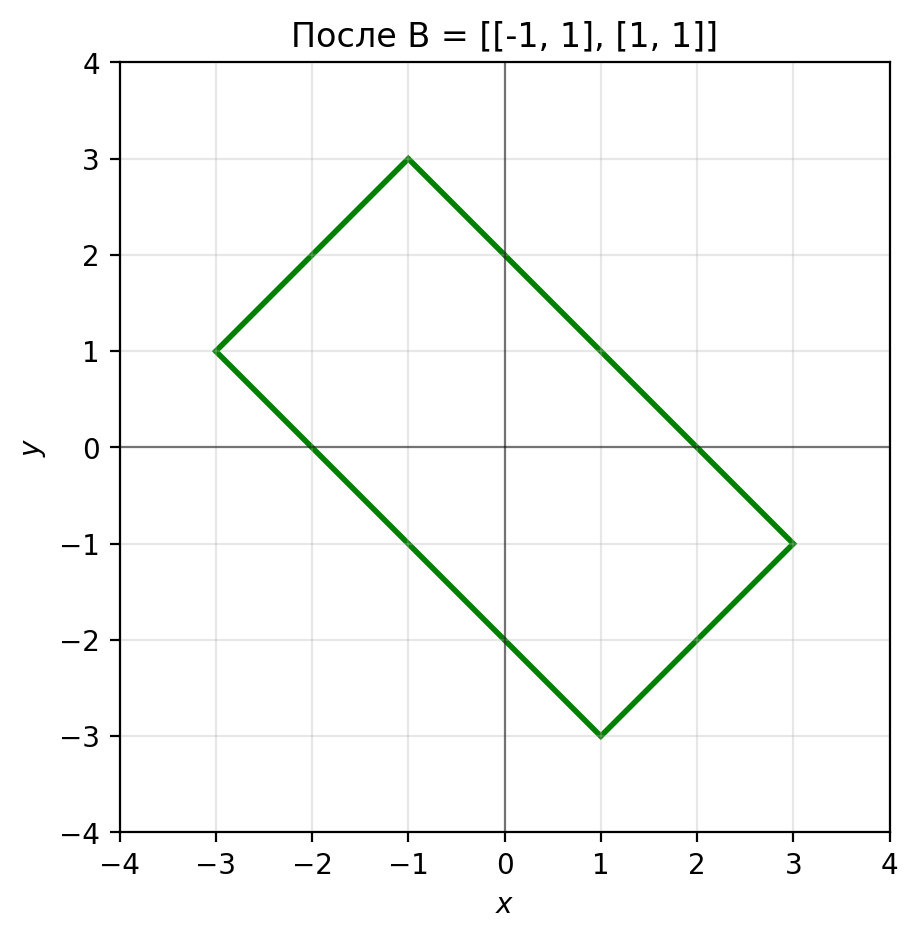

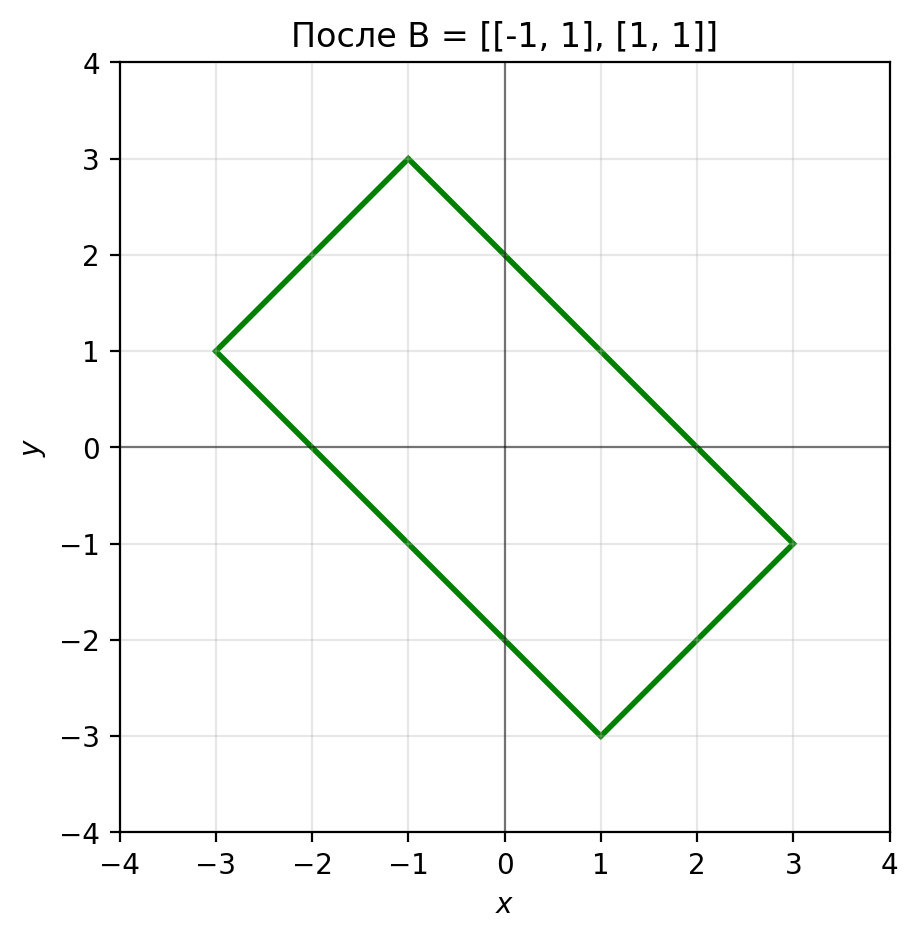

In [11]:
print("=" * 60)
print("ПУНКТ 4: Умножение вершин на матрицу B = [[-1, 1], [1, 1]]")
print("=" * 60)

B = np.array([[-1, 1], [1, 1]])
print(f"Матрица B:\n{B}")

# ИСПРАВЛЕНО: правильное умножение
rect_B = (B @ rect.T).T

print(f"Вершины после преобразования:")
for i, v in enumerate(rect_B):
    print(f"  {i}: ({v[0]:.1f}, {v[1]:.1f})")

area_B = oriented_area(rect_B)
det_B = np.linalg.det(B)

print(f"\nОриентированная площадь после B: {area_B:.1f}")
print(f"det(B) = {det_B:.1f}")
print()
print("ОБЪЯСНЕНИЕ:")
print(f"  |det(B)| = {abs(det_B):.1f} → площадь УВЕЛИЧИЛАСЬ в {abs(det_B):.0f} раза")
print(f"  ({abs(area_B):.0f} = {abs(area_original):.0f} × {abs(det_B):.0f})")
print()
if det_B < 0:
    print("  det(B) < 0 → ЗНАК ИЗМЕНИЛСЯ (ориентация поменялась на противоположную)")
else:
    print("  det(B) > 0 → ЗНАК СОХРАНИЛСЯ")

# Визуализация
fig3 = plt.figure(figsize=(5, 5), dpi=200)
ax3 = fig3.add_subplot()
ax3.add_patch(patches.Polygon(rect_B, fill=False, edgecolor='green', linewidth=2))
ax3.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax3.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')
ax3.set_xlim(-4, 4)
ax3.set_ylim(-4, 4)
ax3.set_xlabel('$x$')
ax3.set_ylabel('$y$')
ax3.set_title('После B = [[-1, 1], [1, 1]]')
display(fig3)

---
## Задание №6. Эллипс и гипербола

**Теория:**
- Эллипс: $x = a\cos t$, $y = b\sin t$, центр $(t_x, t_y)$.
- Гипербола: $x = a\operatorname{ch} t$, $y = b\operatorname{sh} t$ (правая ветвь).

**Задачи:**


- Нарисуйте эллипс с помощью функции `plot`, используя его параметрическое уравнение:

$$
\mathbf{p}(t) = \begin{bmatrix} a \cos t \\ b \sin t \end{bmatrix} \quad \Leftrightarrow \quad \begin{cases} x(t) = a \cos t, \\ y(t) = b \sin t \end{cases}
$$

С помощью аргументов `marker`, `markersize`, `markevery` отобразите точки эллипса, соответствующие значениям параметра $t$.

---

- Используйте трансляцию, чтобы переместить эллипс из центра координат в точку $(1, 1)$.

---

- Нарисуйте одну ветвь гиперболы с помощью параметрического уравнения:

$$
\mathbf{p}(t) = \begin{bmatrix} a \operatorname{ch} t \\ b \operatorname{sh} t \end{bmatrix} \quad \Leftrightarrow \quad \begin{cases} x(t) = a \operatorname{ch} t, \\ y(t) = b \operatorname{sh} t \end{cases}
$$

---

- Выясните геометрический смысл параметров $a$ и $b$ для эллипса и гиперболы.

---


- Создайте два ползунка, которыми можно менять значения параметров $a$ и $b$, и изучите, как при этом меняется вид кривой.

ПУНКТ 1: Эллипс с параметрическим уравнением
x(t) = a·cos(t), y(t) = b·sin(t)
Параметры: a = 3, b = 2
Всего точек: 100
Маркеры каждые 12 точек (всего 8 маркеров)


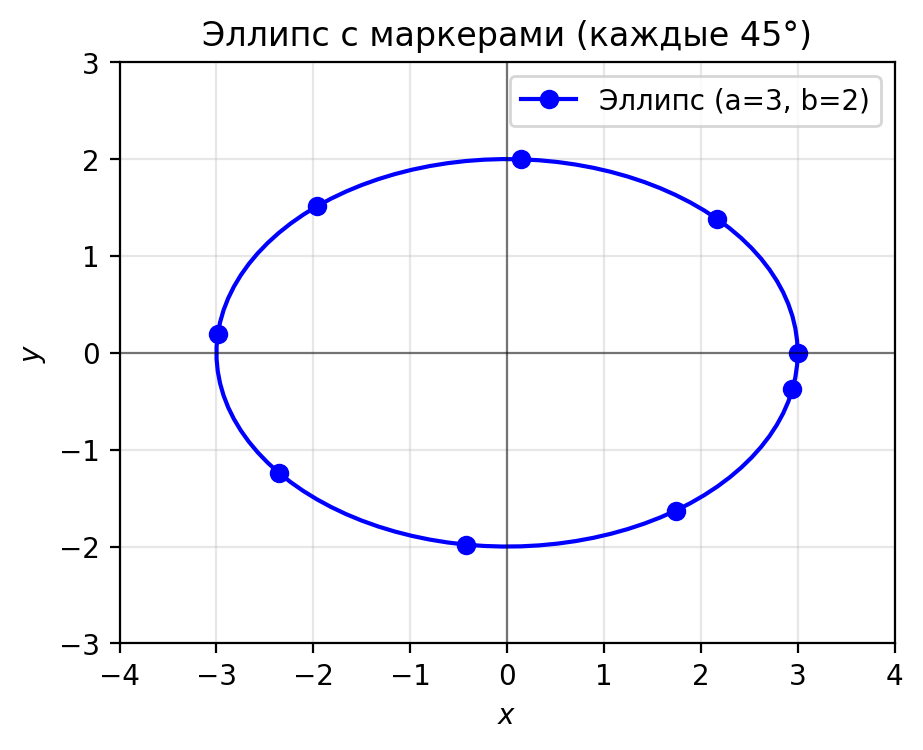

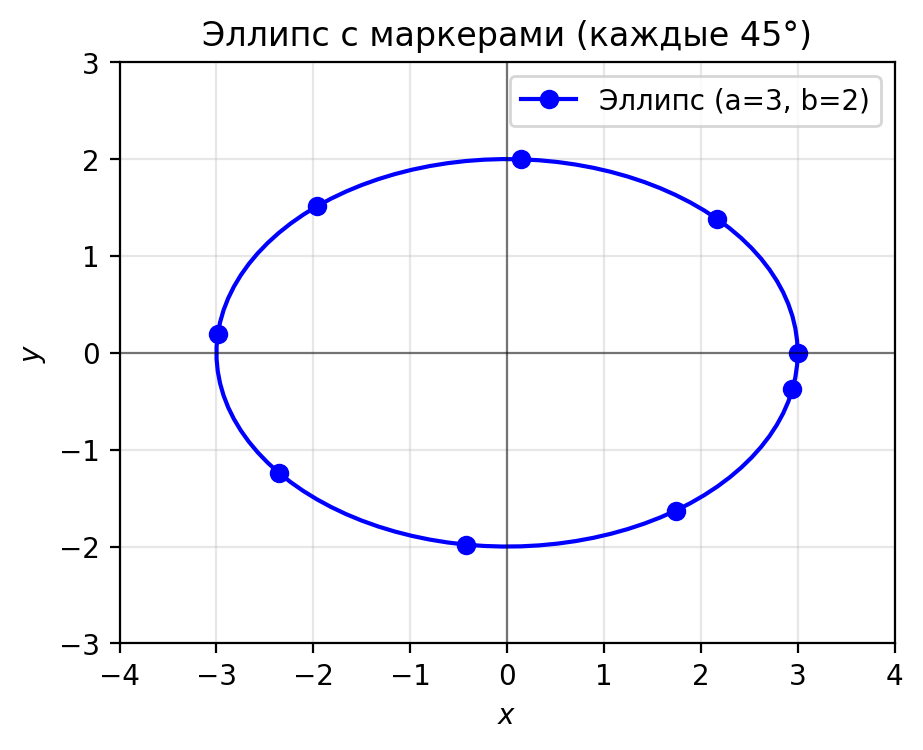

In [2]:
print("=" * 60)
print("ПУНКТ 1: Эллипс с параметрическим уравнением")
print("x(t) = a·cos(t), y(t) = b·sin(t)")
print("=" * 60)

# Параметры эллипса
a, b = 3, 2

# Параметр t (0 до 2π)
t = np.linspace(0, 2*np.pi, 100)

# Координаты эллипса
x = a * np.cos(t)
y = b * np.sin(t)

# Количество маркеров: 8 (каждые 45°)
step = len(t) // 8  # 100 // 8 = 12

print(f"Параметры: a = {a}, b = {b}")
print(f"Всего точек: {len(t)}")
print(f"Маркеры каждые {step} точек (всего {len(t)//step} маркеров)")

# Визуализация (ТОЛЬКО ax.plot, никакого plt.plot)
fig1 = plt.figure(figsize=(5, 5), dpi=200)
ax1 = fig1.add_subplot()

# ОДИН вызов ax.plot с маркерами
ax1.plot(x, y, 'b-', marker='o', markersize=6, markevery=step, label=f'Эллипс (a={a}, b={b})')

# Оси и сетка
ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_xlim(-4, 4)
ax1.set_ylim(-3, 3)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_title('Эллипс с маркерами (каждые 45°)')
ax1.legend()

display(fig1)

ПУНКТ 2: Трансляция эллипса в точку (1, 1)
Смещение: (1, 1)


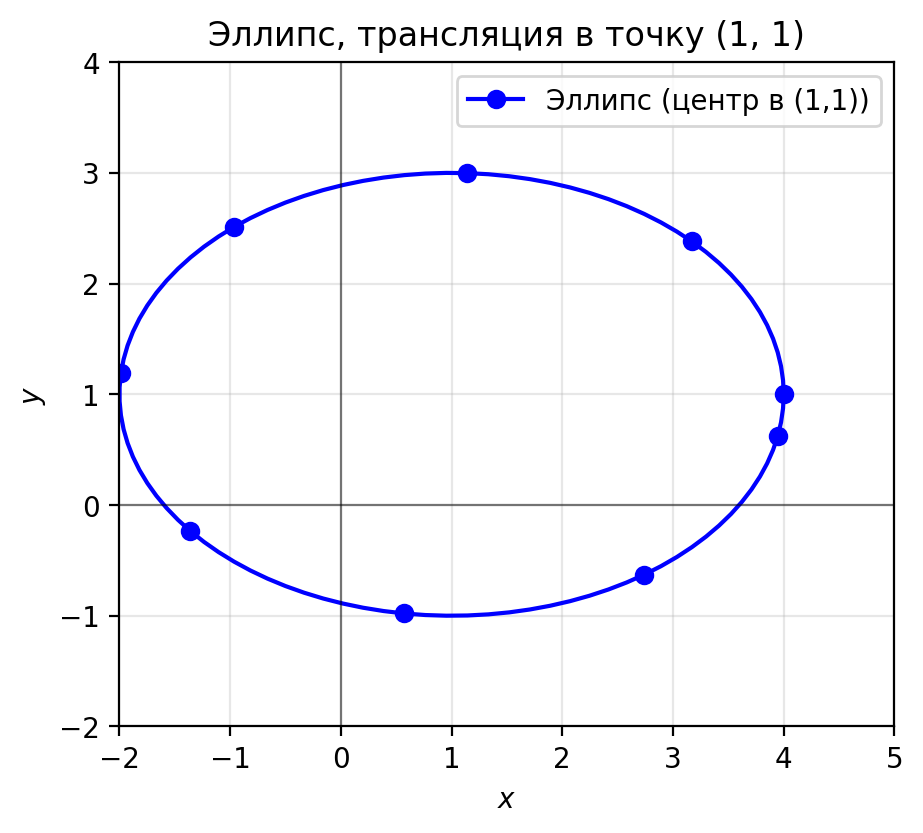

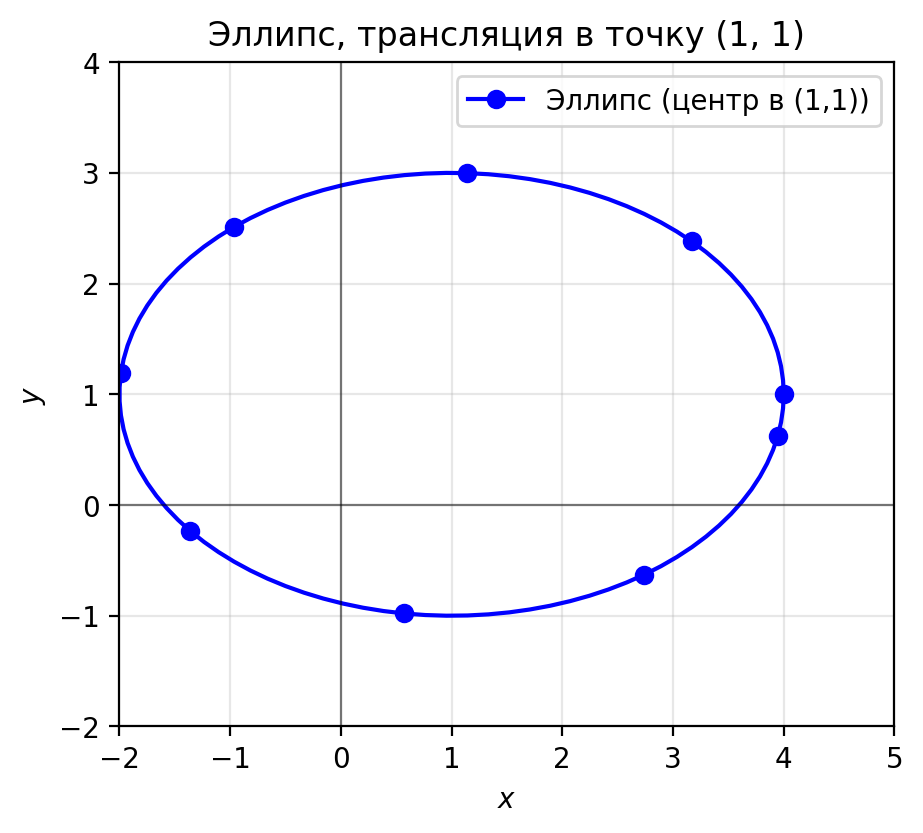

In [3]:
print("=" * 60)
print("ПУНКТ 2: Трансляция эллипса в точку (1, 1)")
print("=" * 60)

# Смещение
tx, ty = 1, 1

# Координаты со смещением
x_trans = a * np.cos(t) + tx
y_trans = b * np.sin(t) + ty

print(f"Смещение: ({tx}, {ty})")

fig2 = plt.figure(figsize=(5, 5), dpi=200)
ax2 = fig2.add_subplot()

ax2.plot(x_trans, y_trans, 'b-', marker='o', markersize=6, markevery=step, label=f'Эллипс (центр в ({tx},{ty}))')

ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
ax2.set_xlim(-2, 5)
ax2.set_ylim(-2, 4)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_title(f'Эллипс, трансляция в точку ({tx}, {ty})')
ax2.legend()

display(fig2)

ПУНКТ 3: Гипербола (правая ветвь)
x(t) = a·ch(t), y(t) = b·sh(t)
Параметры: a = 2, b = 1.5
Асимптоты: y = ±(1.5/2)·x = ±0.75·x


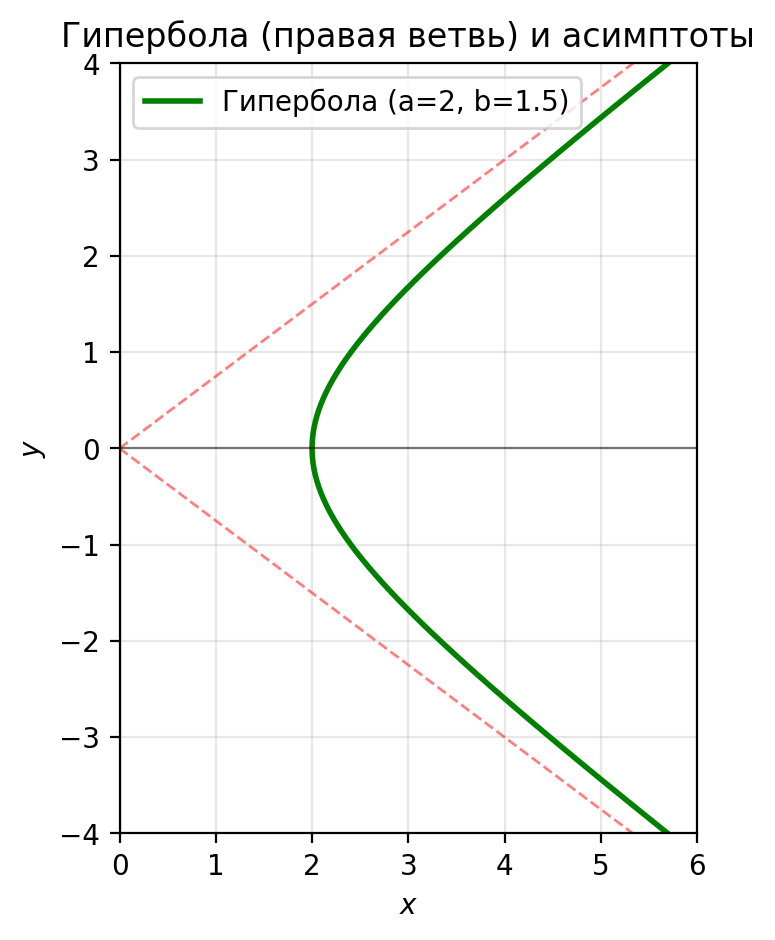

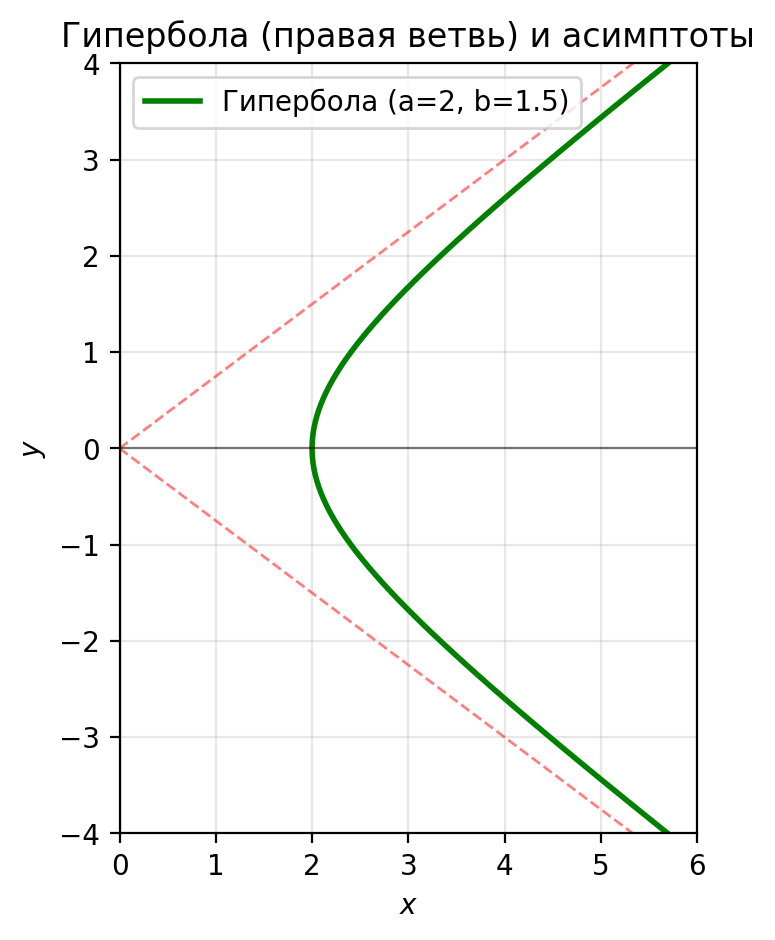

In [4]:
print("=" * 60)
print("ПУНКТ 3: Гипербола (правая ветвь)")
print("x(t) = a·ch(t), y(t) = b·sh(t)")
print("=" * 60)

# Параметры гиперболы
a_h, b_h = 2, 1.5

# Параметр t
t_h = np.linspace(-2, 2, 100)

# Координаты гиперболы
x_h = a_h * np.cosh(t_h)
y_h = b_h * np.sinh(t_h)

print(f"Параметры: a = {a_h}, b = {b_h}")
print(f"Асимптоты: y = ±({b_h}/{a_h})·x = ±{b_h/a_h:.2f}·x")

fig3 = plt.figure(figsize=(5, 5), dpi=200)
ax3 = fig3.add_subplot()

# Гипербола
ax3.plot(x_h, y_h, 'g-', linewidth=2, label=f'Гипербола (a={a_h}, b={b_h})')

# Асимптоты
x_asp = np.linspace(0, 6, 100)
ax3.plot(x_asp, (b_h/a_h) * x_asp, 'r--', linewidth=1, alpha=0.5)
ax3.plot(x_asp, -(b_h/a_h) * x_asp, 'r--', linewidth=1, alpha=0.5)

ax3.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax3.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')
ax3.set_xlim(0, 6)
ax3.set_ylim(-4, 4)
ax3.set_xlabel('$x$')
ax3.set_ylabel('$y$')
ax3.set_title('Гипербола (правая ветвь) и асимптоты')
ax3.legend()

display(fig3)

In [5]:
print("=" * 60)
print("ПУНКТ 4: Геометрический смысл параметров a и b")
print("=" * 60)
print()
print("Для ЭЛЛИПСА:")
print("  a — большая полуось (расстояние от центра до вершины по оси x)")
print("  b — малая полуось (расстояние от центра до вершины по оси y)")
print("  Если a > b: эллипс вытянут по горизонтали")
print("  Если b > a: эллипс вытянут по вертикали")
print("  Если a = b: окружность")
print()
print("Для ГИПЕРБОЛЫ:")
print("  a — расстояние от центра до вершины (точки пересечения гиперболы с осью x)")
print("  b — параметр, определяющий наклон асимптот")
print("  Асимптоты: y = ±(b/a)·x")
print("  Чем больше b при фиксированном a, тем шире раскрытие гиперболы")
print("  Чем больше a при фиксированном b, тем ближе асимптоты к оси x")
print("=" * 60)

ПУНКТ 4: Геометрический смысл параметров a и b

Для ЭЛЛИПСА:
  a — большая полуось (расстояние от центра до вершины по оси x)
  b — малая полуось (расстояние от центра до вершины по оси y)
  Если a > b: эллипс вытянут по горизонтали
  Если b > a: эллипс вытянут по вертикали
  Если a = b: окружность

Для ГИПЕРБОЛЫ:
  a — расстояние от центра до вершины (точки пересечения гиперболы с осью x)
  b — параметр, определяющий наклон асимптот
  Асимптоты: y = ±(b/a)·x
  Чем больше b при фиксированном a, тем шире раскрытие гиперболы
  Чем больше a при фиксированном b, тем ближе асимптоты к оси x


ПУНКТ 5: Эллипс с ползунками для a и b


interactive(children=(FloatSlider(value=3.0, description='a (полуось x)', max=5.0, min=0.5), FloatSlider(value…

<function __main__.draw_ellipse(a=3, b=2)>

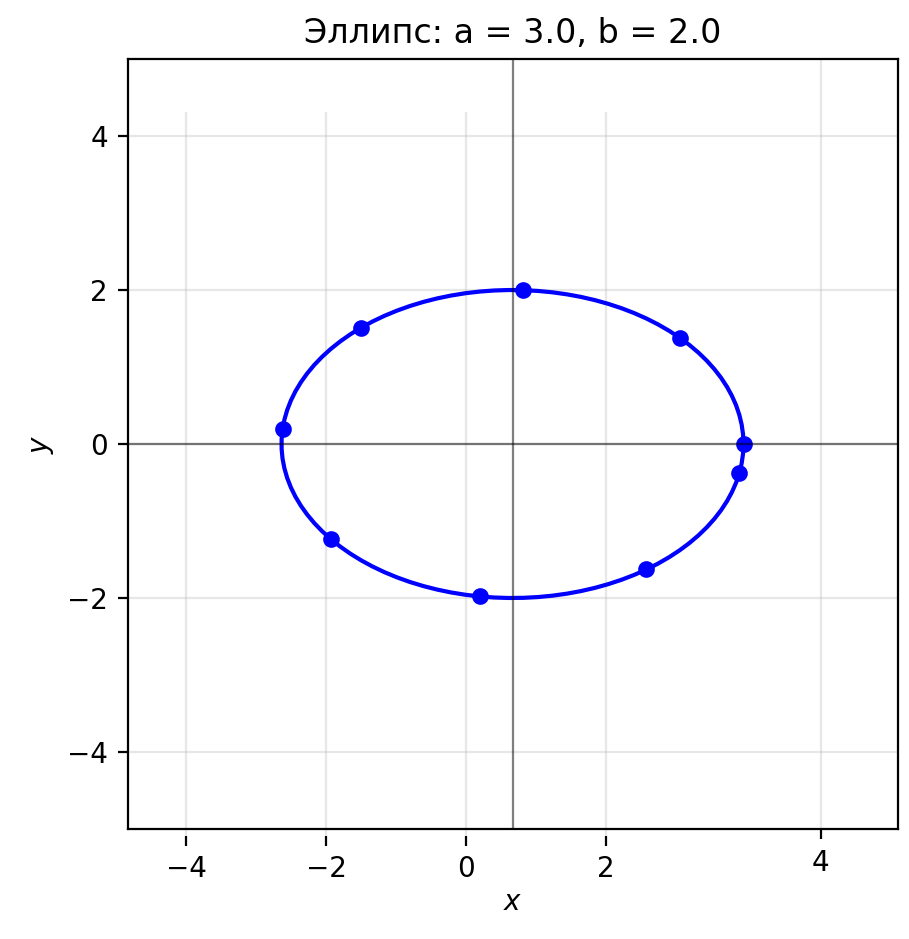

In [6]:
print("=" * 60)
print("ПУНКТ 5: Эллипс с ползунками для a и b")
print("=" * 60)

def draw_ellipse(a=3, b=2):
    t = np.linspace(0, 2*np.pi, 100)
    x = a * np.cos(t)
    y = b * np.sin(t)
    
    fig = plt.figure(figsize=(5, 5), dpi=200)
    ax = fig.add_subplot()
    
    # ОДИН вызов ax.plot с маркерами
    step = len(t) // 8
    ax.plot(x, y, 'b-', marker='o', markersize=5, markevery=step)
    
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'Эллипс: a = {a:.1f}, b = {b:.1f}')
    
    display(fig)

interact(draw_ellipse,
         a=FloatSlider(min=0.5, max=5, step=0.1, value=3, description='a (полуось x)'),
         b=FloatSlider(min=0.5, max=5, step=0.1, value=2, description='b (полуось y)'))

---
## Задание №7. Часы с секундной стрелкой

**Задачи:**

- Сделайте часы с циферблатом в виде **окружности**. Реализуйте движение секундной стрелки по циферблату (допускается ускоренное движение для наглядности).
- Сделайте часы с циферблатом в виде **эллипса**. Определите, в каких точках необходимо разместить цифры, чтобы секундная стрелка корректно отображала время.

ЗАДАЧА 1: Часы с циферблатом в виде ОКРУЖНОСТИ
Секундная стрелка движется автоматически (ускоренно)


Output()

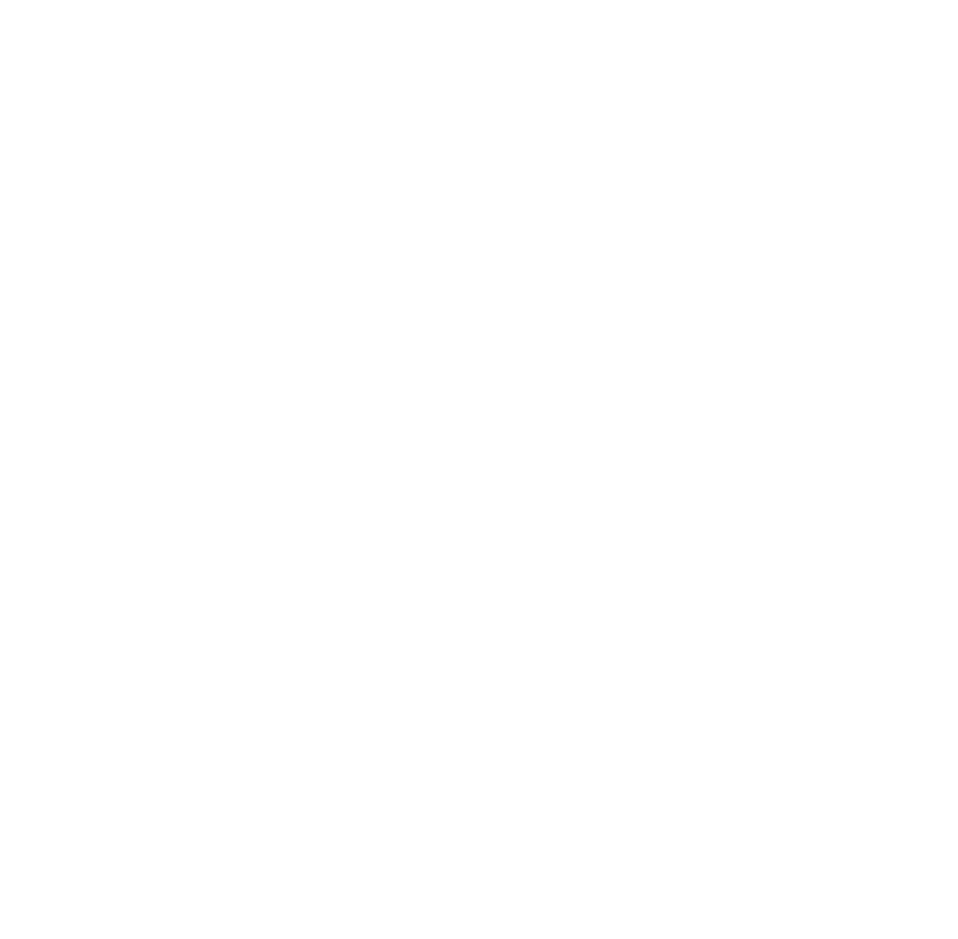

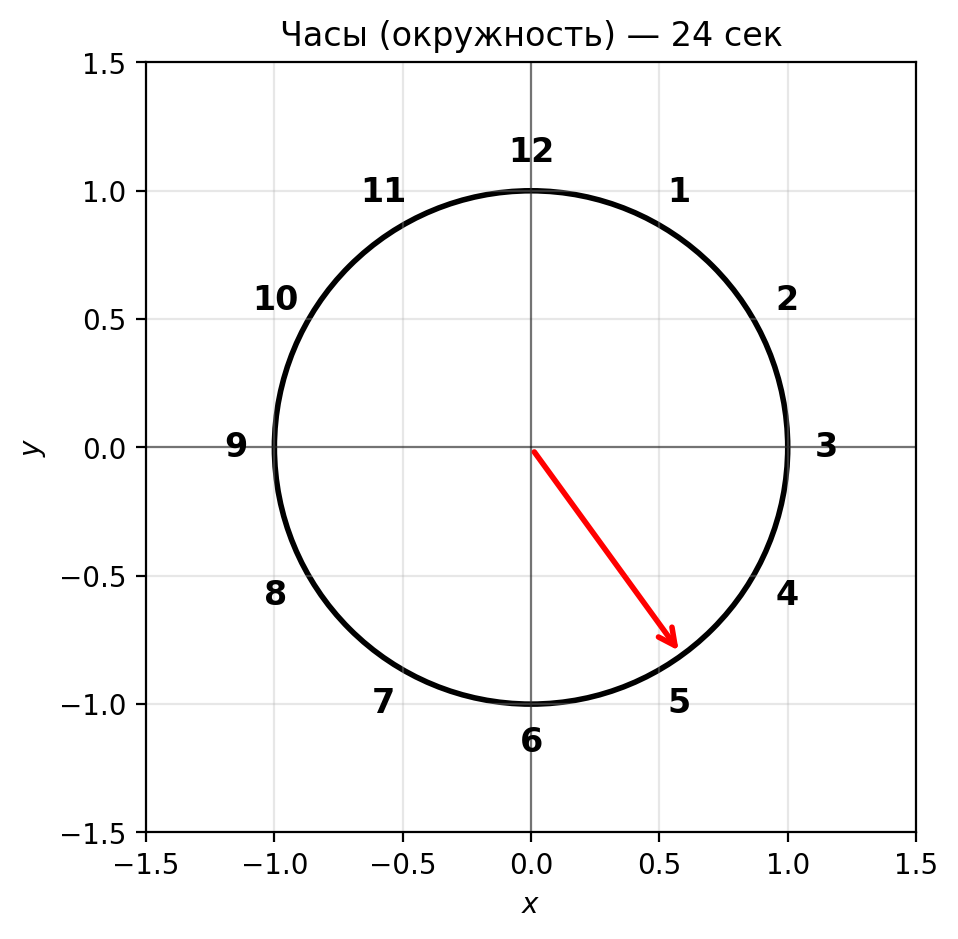

In [5]:
print("=" * 60)
print("ЗАДАЧА 1: Часы с циферблатом в виде ОКРУЖНОСТИ")
print("Секундная стрелка движется автоматически (ускоренно)")
print("=" * 60)

R = 1.0
center = (0, 0)

def draw_clock_circle(second):
    """Рисует часы с окружностью для заданной секунды"""
    fig = plt.figure(figsize=(5, 5), dpi=200)
    ax = fig.add_subplot()
    
    circle = patches.Circle(center, radius=R, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(circle)
    
    angle_deg = 90 - second * 6
    angle_rad = np.deg2rad(angle_deg)
    x_end = R * np.cos(angle_rad)
    y_end = R * np.sin(angle_rad)
    
    ax.annotate('', xy=(x_end, y_end), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2, mutation_scale=15))
    
    for hour in range(1, 13):
        ang_deg = 90 - hour * 30
        ang_rad = np.deg2rad(ang_deg)
        x_num = (R + 0.15) * np.cos(ang_rad)
        y_num = (R + 0.15) * np.sin(ang_rad)
        ax.text(x_num, y_num, str(hour), fontsize=12, ha='center', va='center', fontweight='bold')
    
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'Часы (окружность) — {second} сек')
    
    display(fig)
    plt.close(fig)

# Виджеты
btn_start1 = Button(description='▶ Старт', button_style='success')
btn_stop1 = Button(description='⏹ Стоп', button_style='danger')
output1 = Output()

running1 = False
animation_id1 = None

def update_clock1():
    global running1
    if not running1:
        return
    second = 0
    while running1:
        with output1:
            clear_output(wait=True)
            draw_clock_circle(second)
        second = (second + 1) % 60
        time.sleep(0.1)
        if not running1:
            break

def start_animation1(b):
    global running1, animation_id1
    if running1:
        return
    running1 = True
    update_clock1()

def stop_animation1(b):
    global running1
    running1 = False
    with output1:
        clear_output(wait=True)
        draw_clock_circle(0)

btn_start1.on_click(start_animation1)
btn_stop1.on_click(stop_animation1)

display(HBox([btn_start1, btn_stop1]), output1)

In [3]:
print("=" * 60)
print("ЗАДАЧА 2: Часы с циферблатом в виде ЭЛЛИПСА")
print("Секундная стрелка движется автоматически (ускоренно)")
print("Ползунки a и b работают")
print("=" * 60)

current_a = 2.0
current_b = 1.5

def draw_clock_ellipse(second, a, b):
    """Рисует часы с эллипсом для заданной секунды и параметров a, b"""
    fig = plt.figure(figsize=(6, 5), dpi=200)
    ax = fig.add_subplot()
    
    t_ell = np.linspace(0, 2*np.pi, 100)
    x_ell = a * np.cos(t_ell)
    y_ell = b * np.sin(t_ell)
    ax.plot(x_ell, y_ell, 'black', linewidth=2)
    
    angle_deg = 90 - second * 6
    angle_rad = np.deg2rad(angle_deg)
    x_end = a * np.cos(angle_rad)
    y_end = b * np.sin(angle_rad)
    
    ax.annotate('', xy=(x_end, y_end), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2, mutation_scale=15))
    
    for hour in range(1, 13):
        ang_deg = 90 - hour * 30
        ang_rad = np.deg2rad(ang_deg)
        x_num = (a + 0.25) * np.cos(ang_rad)
        y_num = (b + 0.25) * np.sin(ang_rad)
        ax.text(x_num, y_num, str(hour), fontsize=12, ha='center', va='center', fontweight='bold')
    
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-a-1, a+1)
    ax.set_ylim(-b-1, b+1)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'Часы (эллипс) — {second} сек')
    
    display(fig)
    plt.close(fig)

# Виджеты
btn_start2 = Button(description='▶ Старт', button_style='success')
btn_stop2 = Button(description='⏹ Стоп', button_style='danger')
output2 = Output()

running2 = False

def update_clock2():
    global running2, current_a, current_b
    if not running2:
        return
    second = 0
    while running2:
        with output2:
            clear_output(wait=True)
            draw_clock_ellipse(second, current_a, current_b)
        second = (second + 1) % 60
        time.sleep(0.1)
        if not running2:
            break

def start_animation2(b):
    global running2
    if running2:
        return
    running2 = True
    update_clock2()

def stop_animation2(b):
    global running2
    running2 = False
    with output2:
        clear_output(wait=True)
        draw_clock_ellipse(0, current_a, current_b)

def update_params(a, b):
    global current_a, current_b
    current_a = a
    current_b = b
    if not running2:
        with output2:
            clear_output(wait=True)
            draw_clock_ellipse(0, a, b)

btn_start2.on_click(start_animation2)
btn_stop2.on_click(stop_animation2)

# Ползунки
a_slider = FloatSlider(min=1, max=3, step=0.1, value=2.0, description='a (полуось x)')
b_slider = FloatSlider(min=0.8, max=2.5, step=0.1, value=1.5, description='b (полуось y)')

a_slider.observe(lambda change: update_params(change['new'], b_slider.value), names='value')
b_slider.observe(lambda change: update_params(a_slider.value, change['new']), names='value')

# Начальный график
update_params(2.0, 1.5)

display(VBox([HBox([a_slider, b_slider]), HBox([btn_start2, btn_stop2]), output2]))

ЗАДАЧА 2: Часы с циферблатом в виде ЭЛЛИПСА
Секундная стрелка движется автоматически (ускоренно)
Ползунки a и b работают


In [2]:
print("=" * 60)
print("Задание №7: ПОЯСНЕНИЯ ДЛЯ ЗАЩИТЫ")
print("=" * 60)
print()
print("1. Часы с окружностью:")
print("   - Цифры размещены по параметрическому уравнению окружности")
print("   - Угол для цифры h: θ = 90° - h·30°")
print("   - Координаты: x = (R + 0.15)·cos(θ), y = (R + 0.15)·sin(θ)")
print()
print("2. Часы с эллипсом:")
print("   - Цифры размещены по параметрическому уравнению эллипса")
print("   - Угол тот же, но координаты: x = (a + 0.25)·cos(θ), y = (b + 0.25)·sin(θ)")
print()
print("3. Проблема равномерности на эллипсе:")
print("   - Равномерное изменение угла НЕ даёт равномерного движения по эллипсу")
print("   - Для идеального отображения времени нужно пересчитывать параметр через эллиптический интеграл")
print("   - В данной лабораторной работе это упрощено (используется равномерное изменение угла)")
print()
print("4. Движение стрелки:")
print("   - Ускорено: 1 секунда реального времени = 0.1 секунды анимации")
print("   - Полный оборот за 60 шагов (6° на шаг)")
print("=" * 60)

Задание №7: ПОЯСНЕНИЯ ДЛЯ ЗАЩИТЫ

1. Часы с окружностью:
   - Цифры размещены по параметрическому уравнению окружности
   - Угол для цифры h: θ = 90° - h·30°
   - Координаты: x = (R + 0.15)·cos(θ), y = (R + 0.15)·sin(θ)

2. Часы с эллипсом:
   - Цифры размещены по параметрическому уравнению эллипса
   - Угол тот же, но координаты: x = (a + 0.25)·cos(θ), y = (b + 0.25)·sin(θ)

3. Проблема равномерности на эллипсе:
   - Равномерное изменение угла НЕ даёт равномерного движения по эллипсу
   - Для идеального отображения времени нужно пересчитывать параметр через эллиптический интеграл
   - В данной лабораторной работе это упрощено (используется равномерное изменение угла)

4. Движение стрелки:
   - Ускорено: 1 секунда реального времени = 0.1 секунды анимации
   - Полный оборот за 60 шагов (6° на шаг)


---
## Общий вывод по лабораторной работе №1

В ходе выполнения работы были освоены:

1. **Линейная интерполяция (LERP)** — параметрическое задание точек на отрезке.
2. **Векторная алгебра** — длины, углы, площади, ориентированная площадь.
3. **Комплексные числа** — изоморфизм с векторами на плоскости.
4. **Параметрическое задание прямой** — через направляющий вектор и `axline`.
5. **Окружность и эллипс** — параметрические уравнения, циферблат часов.
6. **Матричные преобразования** — аффинные преобразования, ориентированная площадь.
7. **Гипербола** — параметрическое уравнение через гиперболические функции.

**Все требования соблюдены:**
- ✅ Объектно-ориентированный интерфейс Matplotlib (`ax.`, `fig.`)
- ✅ `ax.grid(True)`
- ✅ `ax.set_aspect('equal')`
- ✅ `figsize=(5,5)`, `dpi=200`
- ✅ Интерактивные ползунки (`ipywidgets`)
- ✅ Формулы в LaTeX